# Thesis Figures

Reads precomputed CSVs only (no metric computation), outputs go to `figures/thesis_figures/`.

In [76]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
from common import constants

FIG_OUT_DIR = REPO_ROOT / "figures" / "thesis_figures"
FIG_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Human + the four LLMs, in the thesis's standard display order
SOURCE_ORDER = ["human", *constants.MODEL_KEYS]
SOURCE_COLORS = {k: constants.MODEL_COLORS[constants.MODEL_LABELS[k]] for k in SOURCE_ORDER}
SOURCE_LABELS = [constants.MODEL_LABELS[s] for s in SOURCE_ORDER]

DOMAINS = ["storytelling_n200", "translation_ref3"]
DOMAIN_LABELS = {"storytelling_n200": "Storytelling", "translation_ref3": "Translation"}

plt.rcParams["figure.dpi"] = 120


def save_fig(name):
    out_path = FIG_OUT_DIR / name
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")


def save_csv(df, name, **kwargs):
    out_path = FIG_OUT_DIR / name
    df.to_csv(out_path, **kwargs)
    print(f"Saved: {out_path}")


def styled_violin(ax, data, colors, labels=None, alpha=0.75):
    """Violins with a solid black median and dotted black Q1/Q3 lines (shared thesis style)."""
    positions = range(1, len(data) + 1)
    parts = ax.violinplot(data, positions=positions, widths=0.7, showmedians=True,
                           showextrema=False, quantiles=[[0.25, 0.75]] * len(data))
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(alpha)
        pc.set_edgecolor('black')
        pc.set_linewidth(0.5)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)
    parts['cquantiles'].set_color('black')
    parts['cquantiles'].set_linewidth(1)
    parts['cquantiles'].set_linestyle(':')
    ax.set_xticks(list(positions))
    if labels is not None:
        ax.set_xticklabels(labels)
    return parts


def data_ylims(data, metric, shared=True):
    """Per-domain (min, max) of `metric`; with shared=True one common range for all domains."""
    ranges = {d: (data[d][metric].min(), data[d][metric].max()) for d in DOMAINS}
    if shared:
        common = (min(lo for lo, _ in ranges.values()), max(hi for _, hi in ranges.values()))
        ranges = {d: common for d in DOMAINS}
    return ranges


def source_violin_grid(data, metrics, metric_labels, title, out_name, ylims=None):
    """Rows = metrics, columns = domains, one violin per source. `data[domain]` is wide
    (a `source` column plus one column per metric); `ylims(metric)` optionally returns
    {domain: (lo, hi)} to pin the y-axis to the data range with a 5% margin."""
    fig, axes = plt.subplots(len(metrics), len(DOMAINS),
                             figsize=(len(DOMAINS) * 3.6, len(metrics) * 2.2), squeeze=False)
    for row, metric in enumerate(metrics):
        row_ylim = ylims(metric) if ylims else None
        for col, domain in enumerate(DOMAINS):
            ax = axes[row][col]
            df = data[domain]
            styled_violin(ax, [df.loc[df['source'] == s, metric].dropna().values for s in SOURCE_ORDER],
                          [SOURCE_COLORS[s] for s in SOURCE_ORDER])
            ax.set_ylabel(metric_labels[metric] if col == 0 else '')
            if row_ylim:
                lo, hi = row_ylim[domain]
                pad = (hi - lo) * 0.05 or 1.0
                ax.set_ylim(lo - pad, hi + pad)
            ax.set_xticklabels(SOURCE_LABELS if row == len(metrics) - 1 else [], rotation=45, ha='right')
            if row == 0:
                ax.set_title(DOMAIN_LABELS[domain], fontsize=12, fontweight='bold')
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    save_fig(out_name)


def domain_pivot(df, values, index_labels, metrics):
    """Long frame (domain, source_label, metric) -> rows = source, columns = (domain, metric)."""
    cols = pd.MultiIndex.from_product([DOMAINS, metrics], names=['domain', 'metric'])
    table = (df.pivot(index='source_label', columns=['domain', 'metric'], values=values)
               .reindex(index=index_labels, columns=cols))
    table.columns = table.columns.set_levels(
        [DOMAIN_LABELS[d] for d in table.columns.levels[0]], level='domain')
    return table

## Discourse Diversity

Source: `metrics/01_discourse_diversity/disc_diversity.ipynb`

### Pooled transition profiles

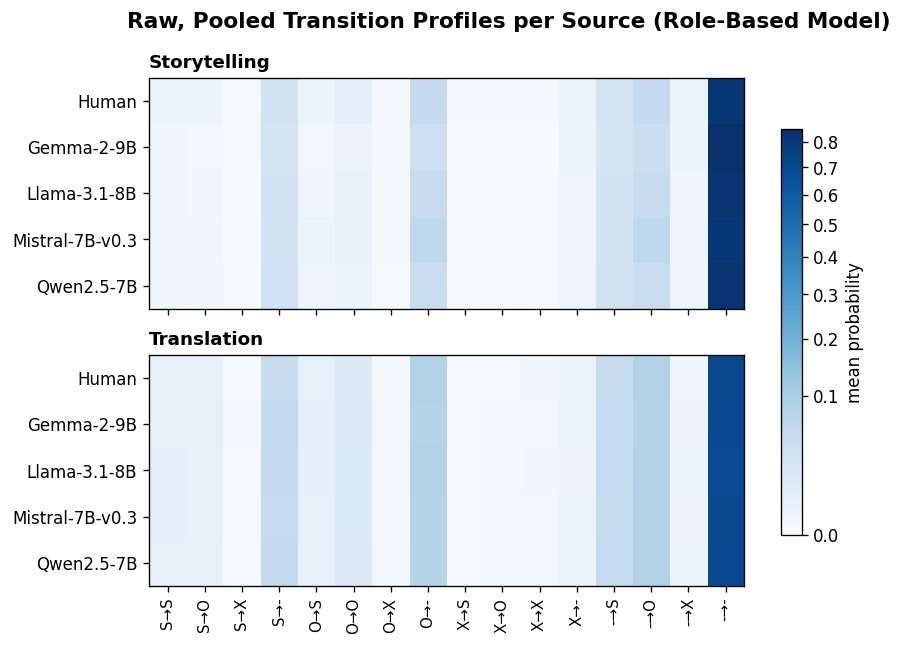

Saved: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/figures/thesis_figures/discourse_pooled_transition_profiles_combined.png


In [77]:
from matplotlib.colors import PowerNorm

DISC_TABLE_DIR = REPO_ROOT / "metrics" / "01_discourse_diversity" / "tables"
profiles = {
    d: pd.read_csv(DISC_TABLE_DIR / d / "mean_transition_profile.csv", index_col="source").reindex(SOURCE_ORDER)
    for d in DOMAINS
}

fig, axes = plt.subplots(len(DOMAINS), 1, figsize=(8, 5.5), sharex=True)
vmax = max(df.to_numpy().max() for df in profiles.values())
norm = PowerNorm(gamma=0.5, vmin=0, vmax=vmax)

for ax, domain in zip(axes, DOMAINS):
    df = profiles[domain]
    im = ax.imshow(df.to_numpy(), cmap="Blues", aspect="auto", norm=norm)
    ax.set_yticks(range(len(df.index)))
    ax.set_yticklabels([constants.MODEL_LABELS[s] for s in df.index])
    ax.set_title(DOMAIN_LABELS[domain], fontsize=11, fontweight="bold", loc="left")

bigram_cols = profiles[DOMAINS[0]].columns
axes[-1].set_xticks(range(len(bigram_cols)))
axes[-1].set_xticklabels([f"{c[0]}→{c[1]}" for c in bigram_cols], rotation=90, fontsize=9)

fig.suptitle("Raw, Pooled Transition Profiles per Source (Role-Based Model)",
             fontsize=13, fontweight="bold")
fig.colorbar(im, ax=axes, shrink=0.8, label="mean probability")
save_fig("discourse_pooled_transition_profiles_combined.png")

## Stylistic Diversity

Source: `metrics/02_stylistic_diversity/stylistic_diversity.ipynb`

In [78]:
STYLE_TABLE_DIR = REPO_ROOT / "metrics" / "02_stylistic_diversity" / "tables"
style_data = {d: pd.read_csv(STYLE_TABLE_DIR / d / "style_features_per_text.csv") for d in DOMAINS}

# The 7 scalar features kept after redundancy removal
STYLE_FEATURE_LABELS = {
    'sent_len_mean': 'Mean Sentence\nLength',
    'sent_len_var': 'Sentence Length\nVariance',
    'adj_adv_ratio': 'Adjective + Adverb\nRatio',
    'mean_syllables': 'Mean Word Length\n(Syllables)',
    'dialogue_ratio': 'Quotation-Mark\nDensity',
    'punct_expressivity': 'Punctuation\nExpressivity',
    'sent_start_pron_ratio': 'Sentence-Initial\nPronoun Ratio',
}

### Feature distributions

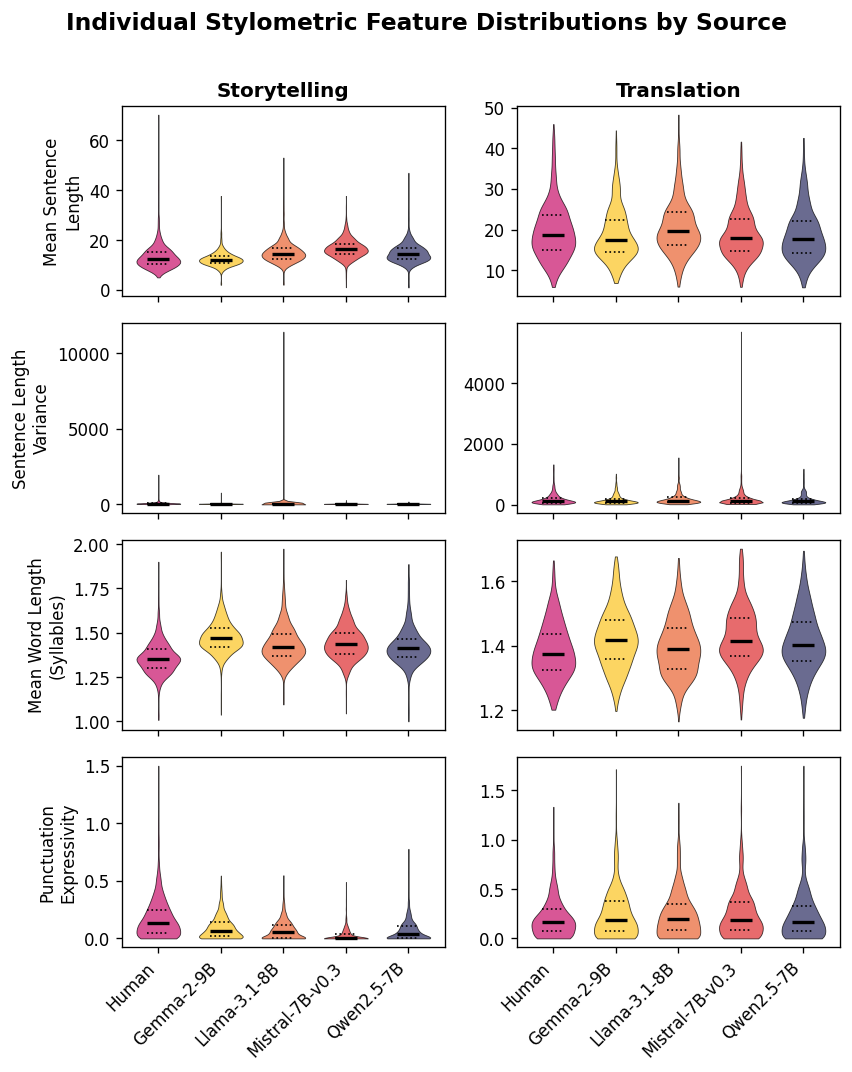

Saved: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/figures/thesis_figures/stylistic_feature_distributions_main.png


In [79]:
source_violin_grid(
    style_data,
    ['sent_len_mean', 'sent_len_var', 'mean_syllables', 'punct_expressivity'],
    STYLE_FEATURE_LABELS,
    "Individual Stylometric Feature Distributions by Source",
    "stylistic_feature_distributions_main.png",
)

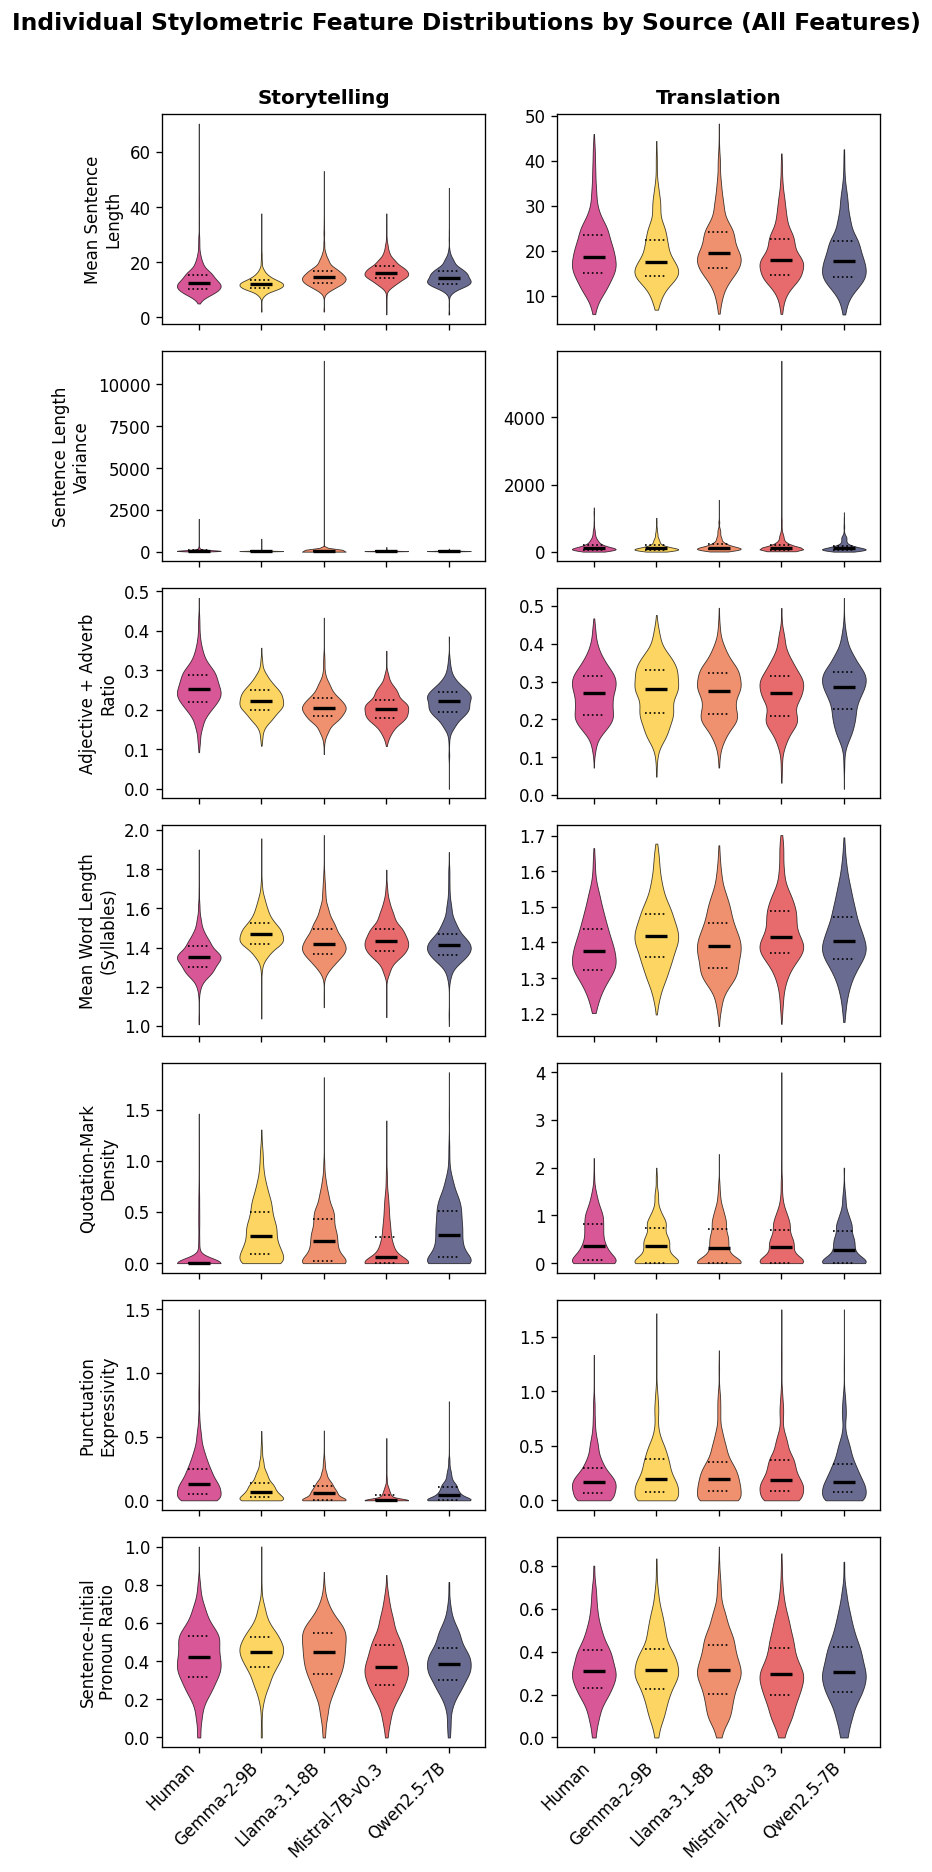

Saved: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/figures/thesis_figures/stylistic_feature_distributions_appendix.png


In [80]:
source_violin_grid(
    style_data,
    list(STYLE_FEATURE_LABELS),
    STYLE_FEATURE_LABELS,
    "Individual Stylometric Feature Distributions by Source (All Features)",
    "stylistic_feature_distributions_appendix.png",
)

## Narrative Diversity

Source: `metrics/03_narrative_diversity/narrative_diversity.ipynb`

### Diversity profile & sentiment trajectory

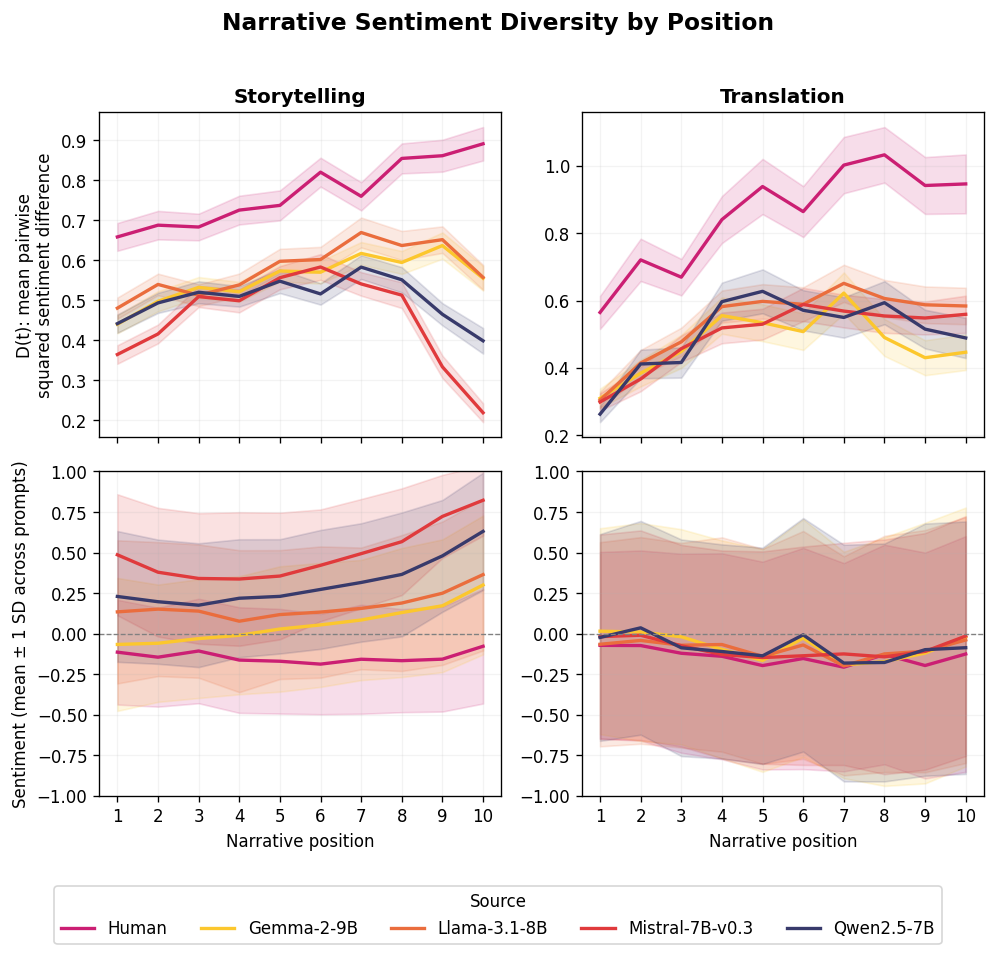

Saved: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/figures/thesis_figures/narrative_diversity_profile_and_sentiment_combined.png


In [81]:
NARR_TABLE_DIR = REPO_ROOT / "metrics" / "03_narrative_diversity" / "tables"
diversity_profile = {d: pd.read_csv(NARR_TABLE_DIR / d / "diversity_profile_by_position.csv") for d in DOMAINS}
sentiment_arcs = {d: pd.read_csv(NARR_TABLE_DIR / d / "aggregated_sentiment_arcs.csv") for d in DOMAINS}

ARC_LENGTH = 10  # narrative position bins 1..ARC_LENGTH
narr_xticks = np.arange(1, ARC_LENGTH + 1)

# (data, mean column, band half-width column, y-label) per row
NARR_ROWS = [
    (diversity_profile, 'mean_D', 'se_D', 'D(t): mean pairwise\nsquared sentiment difference'),
    (sentiment_arcs, 'mean_sentiment', 'std_sentiment', 'Sentiment (mean ± 1 SD across prompts)'),
]

fig, axes = plt.subplots(2, len(DOMAINS), figsize=(len(DOMAINS) * 4.2, 7), sharex=True)
for row, (data, mean_col, band_col, ylabel) in enumerate(NARR_ROWS):
    for col, domain in enumerate(DOMAINS):
        ax = axes[row][col]
        df = data[domain]
        for source in SOURCE_ORDER:
            sub = df[df['source'] == source].sort_values('position')
            if sub.empty:
                continue
            color = SOURCE_COLORS[source]
            ax.plot(sub['position'], sub[mean_col], label=constants.MODEL_LABELS[source],
                    color=color, linewidth=2)
            ax.fill_between(sub['position'], sub[mean_col] - sub[band_col],
                            sub[mean_col] + sub[band_col], alpha=0.15, color=color)
        ax.set_xticks(narr_xticks)
        ax.grid(True, alpha=0.15)
        if col == 0:
            ax.set_ylabel(ylabel)
        if row == 0:
            ax.set_title(DOMAIN_LABELS[domain], fontsize=12, fontweight='bold')
        else:
            ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
            ax.set_ylim(-1, 1)
            ax.set_xlabel('Narrative position')

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, title='Source', loc='lower center',
           bbox_to_anchor=(0.5, -0.1), ncol=len(SOURCE_ORDER))
fig.suptitle('Narrative Sentiment Diversity by Position', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig("narrative_diversity_profile_and_sentiment_combined.png")

## Within-Group Diversity

Sources: `metrics/06_writingprompts_diversity/` (Storytelling), `metrics/07_par3_diversity/` (Translation)

### Distributions by source

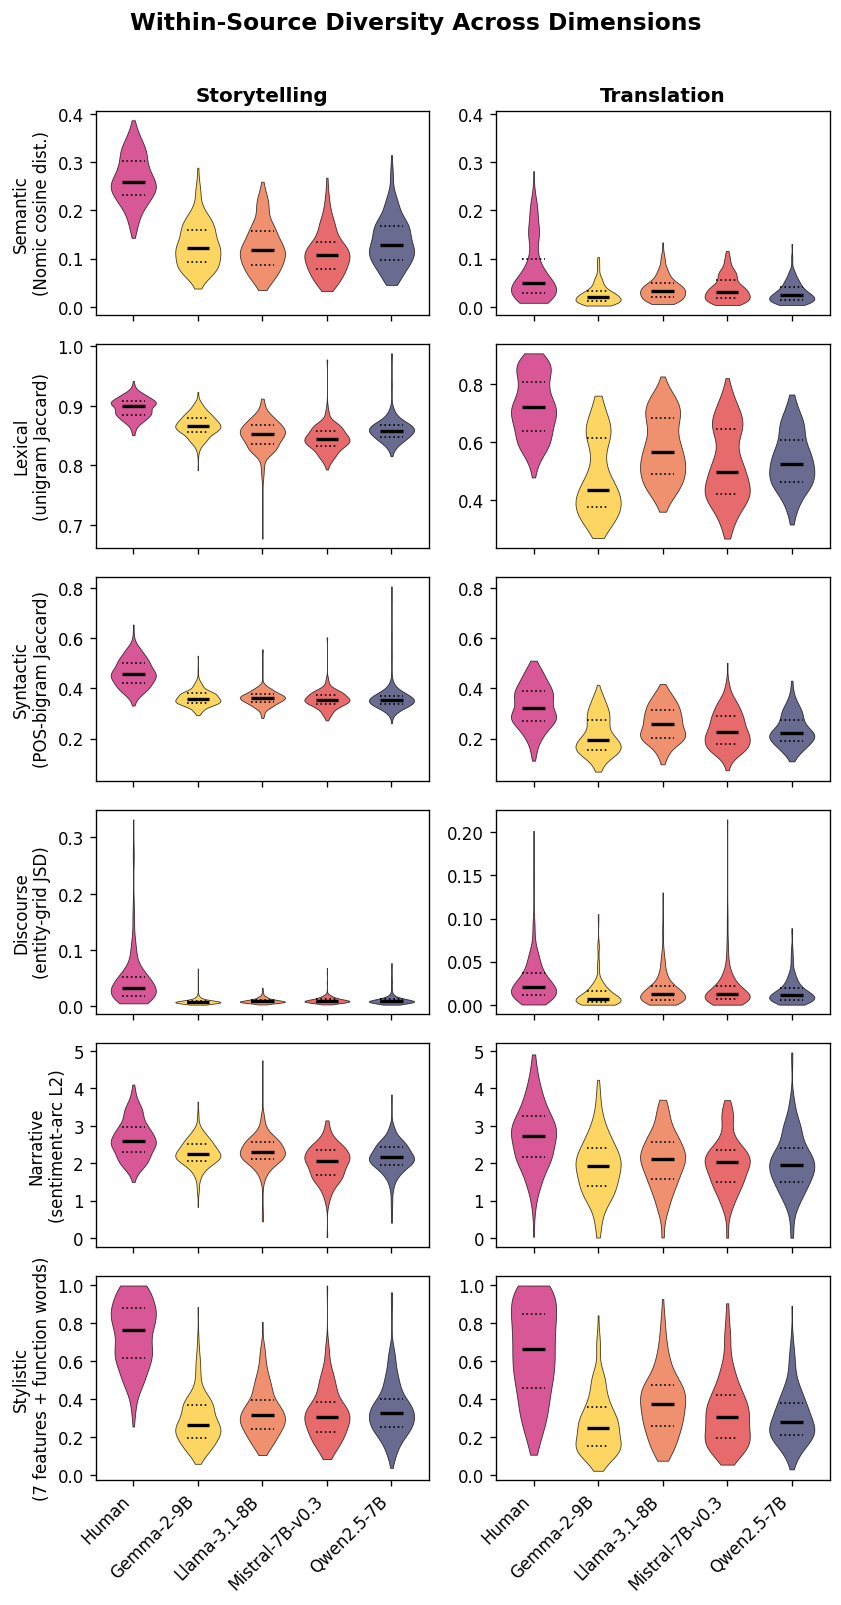

Saved: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/figures/thesis_figures/within_group_diversity_by_source_combined.png


In [82]:
GROUP_METRICS = ['D_sem', 'D_lex', 'D_syn', 'D_disc', 'D_narr', 'D_style']

GROUP_METRIC_LABELS = {
    'D_sem': 'Semantic\n(Nomic cosine dist.)',
    'D_lex': 'Lexical\n(unigram Jaccard)',
    'D_syn': 'Syntactic\n(POS-bigram Jaccard)',
    'D_disc': 'Discourse\n(entity-grid JSD)',
    'D_narr': 'Narrative\n(sentiment-arc L2)',
    'D_style': 'Stylistic\n(7 features + function words)',
}

# Storytelling vs. Translation ranges differ too much for a shared y-scale on these two
UNSHARED_SCALE_METRICS = {'D_lex', 'D_disc'}

GROUP_CACHE_DIRS = {
    "storytelling_n200": REPO_ROOT / "metrics" / "06_writingprompts_diversity" / "cache",
    "translation_ref3": REPO_ROOT / "metrics" / "07_par3_diversity" / "cache",
}


def newest_cache(cache_dir, pattern):
    matches = sorted(cache_dir.glob(pattern), key=lambda p: p.stat().st_mtime)
    if not matches:
        raise FileNotFoundError(f"No {pattern} found in {cache_dir}")
    return matches[-1]


def load_group_metrics(cache_dir):
    """Join the newest per-metric caches into one frame, one row per (source, prompt)."""
    merged = None
    for metric in GROUP_METRICS:
        df = pd.read_csv(newest_cache(cache_dir, f"cache_{metric.lower()}*.csv"))
        df = df[['group_id', 'model_key', 'prompt_id', metric]]
        merged = df if merged is None else merged.merge(df, on=['group_id', 'model_key', 'prompt_id'], how='outer')
    return merged.rename(columns={'model_key': 'source'})


group_data = {d: load_group_metrics(p) for d, p in GROUP_CACHE_DIRS.items()}

source_violin_grid(
    group_data, GROUP_METRICS, GROUP_METRIC_LABELS,
    'Within-Source Diversity Across Dimensions',
    "within_group_diversity_by_source_combined.png",
    ylims=lambda m: data_ylims(group_data, m, shared=m not in UNSHARED_SCALE_METRICS),
)

### Descriptive statistics

In [83]:
summary_df = (
    pd.concat([group_data[d].assign(domain=d) for d in DOMAINS])
    .melt(id_vars=['domain', 'source'], value_vars=GROUP_METRICS, var_name='metric')
    .groupby(['domain', 'source', 'metric'])['value']
    .agg(mean='mean', median='median', std='std', n='count')
    .reset_index()
)
summary_df['mean_std'] = (
    summary_df['mean'].round(3).astype(str) + ' (med '
    + summary_df['median'].round(3).astype(str) + ') ± '
    + summary_df['std'].round(3).astype(str)
)
save_csv(summary_df, "within_group_diversity_summary_stats.csv", index=False)

summary_df['source_label'] = summary_df['source'].map(constants.MODEL_LABELS)
print("Mean (median) ± SD:")
display(domain_pivot(summary_df, 'mean_std', SOURCE_LABELS, GROUP_METRICS))
print("\nn groups:")
display(domain_pivot(summary_df, 'n', SOURCE_LABELS, GROUP_METRICS))

Saved: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/figures/thesis_figures/within_group_diversity_summary_stats.csv
Mean (median) ± SD:


domain                        Storytelling                             \
metric                               D_sem                      D_lex   
source_label                                                            
Human             0.265 (med 0.26) ± 0.051    0.897 (med 0.9) ± 0.017   
Gemma-2-9B       0.129 (med 0.122) ± 0.048  0.867 (med 0.867) ± 0.019   
Llama-3.1-8B     0.124 (med 0.117) ± 0.049  0.851 (med 0.853) ± 0.026   
Mistral-7B-v0.3  0.112 (med 0.107) ± 0.046  0.845 (med 0.844) ± 0.021   
Qwen2.5-7B       0.136 (med 0.129) ± 0.051    0.86 (med 0.858) ± 0.02   

domain                                                                 \
metric                               D_syn                     D_disc   
source_label                                                            
Human            0.463 (med 0.456) ± 0.056  0.047 (med 0.033) ± 0.048   
Gemma-2-9B       0.362 (med 0.357) ± 0.031  0.009 (med 0.008) ± 0.006   
Llama-3.1-8B     0.363 (med 0.362) ± 0.033   0.01 (med 0.009) ± 0.005   
Mistral-7B-v0.3  0.357 (med 0.354) ± 0.035   0.011 (med 0.01) ± 0.007   
Qwen2.5-7B       0.361 (med 0.353) ± 0.055  0.011 (med 0.009) ± 0.009   

domain                                                                 \
metric                              D_narr                    D_style   
source_label                                                            
Human             2.653 (med 2.589) ± 0.52  0.746 (med 0.768) ± 0.171   
Gemma-2-9B       2.275 (med 2.257) ± 0.369   0.292 (med 0.266) ± 0.13   
Llama-3.1-8B     2.315 (med 2.309) ± 0.439   0.336 (med 0.316) ± 0.13   
Mistral-7B-v0.3  2.019 (med 2.069) ± 0.465  0.326 (med 0.308) ± 0.137   
Qwen2.5-7B        2.149 (med 2.16) ± 0.423  0.345 (med 0.328) ± 0.146   

domain                         Translation                             \
metric                               D_sem                      D_lex   
source_label                                                            
Human             0.074 (med 0.05) ± 0.062  0.722 (med 0.721) ± 0.105   
Gemma-2-9B        0.026 (med 0.021) ± 0.02  0.479 (med 0.435) ± 0.131   
Llama-3.1-8B     0.039 (med 0.034) ± 0.024  0.581 (med 0.567) ± 0.111   
Mistral-7B-v0.3  0.038 (med 0.032) ± 0.026   0.523 (med 0.496) ± 0.13   
Qwen2.5-7B        0.03 (med 0.024) ± 0.021  0.537 (med 0.525) ± 0.098   

domain                                                                 \
metric                               D_syn                     D_disc   
source_label                                                            
Human            0.328 (med 0.324) ± 0.085   0.028 (med 0.02) ± 0.027   
Gemma-2-9B       0.215 (med 0.194) ± 0.078  0.013 (med 0.007) ± 0.016   
Llama-3.1-8B      0.26 (med 0.257) ± 0.071  0.018 (med 0.013) ± 0.018   
Mistral-7B-v0.3  0.236 (med 0.225) ± 0.075  0.018 (med 0.012) ± 0.023   
Qwen2.5-7B       0.234 (med 0.222) ± 0.064  0.015 (med 0.011) ± 0.015   

domain                                                                 
metric                              D_narr                    D_style  
source_label                                                           
Human            2.729 (med 2.732) ± 0.861  0.647 (med 0.663) ± 0.241  
Gemma-2-9B       1.924 (med 1.927) ± 0.791  0.275 (med 0.252) ± 0.155  
Llama-3.1-8B     2.082 (med 2.117) ± 0.756  0.383 (med 0.378) ± 0.169  
Mistral-7B-v0.3   1.992 (med 2.018) ± 0.72  0.332 (med 0.308) ± 0.176  
Qwen2.5-7B         2.0 (med 1.957) ± 0.788   0.308 (med 0.28) ± 0.144


n groups:


domain          Storytelling                                   Translation  \
metric                 D_sem D_lex D_syn D_disc D_narr D_style       D_sem   
source_label                                                                 
Human                    200   200   200    200    198     200         200   
Gemma-2-9B               200   200   200    200    200     200         196   
Llama-3.1-8B             200   200   200    199    199     199         200   
Mistral-7B-v0.3          200   200   200    200    200     200         200   
Qwen2.5-7B               200   200   200    200    200     199         181   

domain                                             
metric          D_lex D_syn D_disc D_narr D_style  
source_label                                       
Human             200   200    199    186     200  
Gemma-2-9B        196   196    193    194     196  
Llama-3.1-8B      200   200    198    198     200  
Mistral-7B-v0.3   200   200    197    199     200  
Qwen2.5-7B        181   181    179    178     181

### Metric intercorrelations (Spearman)

Upper triangle = Storytelling, lower triangle = Translation.

In [84]:
corr_story, corr_trans = (group_data[d][GROUP_METRICS].corr(method='spearman') for d in DOMAINS)
upper = np.triu(np.ones(corr_story.shape, dtype=bool), k=1)
combined_corr = corr_trans.where(~upper, corr_story)  # upper = Storytelling, lower + diagonal = Translation

save_csv(combined_corr, "metric_intercorrelations_combined.csv")
print(f"Upper = Storytelling (n={len(group_data[DOMAINS[0]])} groups), "
      f"lower = Translation (n={len(group_data[DOMAINS[1]])} groups)")
display(combined_corr.round(2))

Saved: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/figures/thesis_figures/metric_intercorrelations_combined.csv
Upper = Storytelling (n=1000 groups), lower = Translation (n=977 groups)


,D_sem,D_lex,D_syn,D_disc,D_narr,D_style
D_sem,1.00,0.72,0.58,0.53,0.33,0.67
D_lex,0.62,1.00,0.59,0.44,0.39,0.57
D_syn,0.63,0.82,1.00,0.55,0.36,0.58
D_disc,0.32,0.36,0.53,1.00,0.27,0.57
D_narr,0.31,0.45,0.53,0.47,1.00,0.31
D_style,0.61,0.75,0.79,0.56,0.51,1.00


### Baseline metrics by source

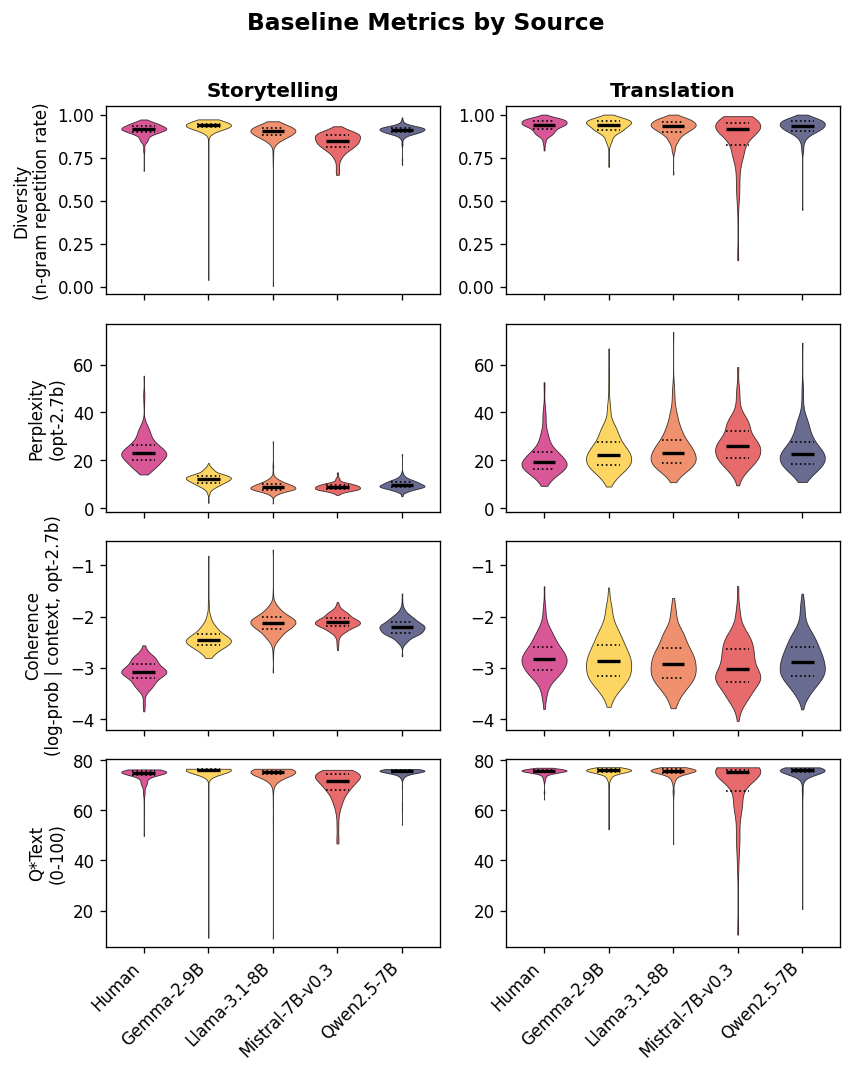

Saved: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/figures/thesis_figures/baseline_metrics_by_source_combined.png


In [85]:
BASELINE_METRICS = ['DIV', 'Perplexity', 'Coherence', 'QStarText']

BASELINE_METRIC_LABELS = {
    'DIV': 'Diversity\n(n-gram repetition rate)',
    'Perplexity': 'Perplexity\n(opt-2.7b)',
    'Coherence': 'Coherence\n(log-prob | context, opt-2.7b)',
    'QStarText': 'Q*Text\n(0-100)',
}


def load_baseline_metrics(cache_dir):
    """Newest per-text baseline cache, averaged to one value per (source, prompt)."""
    df = pd.read_csv(newest_cache(cache_dir, "cache_baseline_metrics_*.csv")).rename(columns={'model_key': 'source'})
    return df.groupby(['source', 'prompt_id'])[BASELINE_METRICS].mean().reset_index()


baseline_data = {d: load_baseline_metrics(p) for d, p in GROUP_CACHE_DIRS.items()}

source_violin_grid(
    baseline_data, BASELINE_METRICS, BASELINE_METRIC_LABELS,
    'Baseline Metrics by Source',
    "baseline_metrics_by_source_combined.png",
    ylims=lambda m: data_ylims(baseline_data, m),
)

## Human-Relative Location

Sources: `metrics/06_writingprompts_diversity/` (Storytelling), `metrics/07_par3_diversity/` (Translation)

In [86]:
HRD_TABLE_DIRS = {
    "storytelling_n200": REPO_ROOT / "metrics" / "06_writingprompts_diversity" / "tables",
    "translation_ref3": REPO_ROOT / "metrics" / "07_par3_diversity" / "tables",
}
MODEL_SOURCES = constants.MODEL_KEYS  # the four LLMs, excluding human
MODEL_LABEL_ORDER = [constants.MODEL_LABELS[mk] for mk in MODEL_SOURCES]
PAIRING_METRICS = GROUP_METRICS


def load_hrd_table(name):
    """Read `<name>.csv` from both domains' `tables/` dirs, keyed by domain."""
    return {d: pd.read_csv(p / f"{name}.csv") for d, p in HRD_TABLE_DIRS.items() if (p / f"{name}.csv").exists()}


def fmt_ci(df, mean='mean', lo='ci_lo', hi='ci_hi', median='median', n='n_prompts'):
    """'mean (med x) [lo, hi] (n=k)' strings; pass median=None to omit the median."""
    s = df[mean].round(3).astype(str)
    if median:
        s = s + ' (med ' + df[median].round(3).astype(str) + ')'
    return (s + ' [' + df[lo].round(3).astype(str) + ', ' + df[hi].round(3).astype(str)
            + '] (n=' + df[n].astype(str) + ')')


def ci_summary_table(summary, out_name):
    """Save both domains' CI summaries as one long CSV; return the formatted pivot."""
    long = pd.concat([df.assign(domain=d) for d, df in summary.items()], ignore_index=True)
    long['formatted'] = fmt_ci(long)
    save_csv(long, out_name, index=False)
    long['source_label'] = long['source'].map(constants.MODEL_LABELS)
    return domain_pivot(long, 'formatted', MODEL_LABEL_ORDER, PAIRING_METRICS)


def hrd_grid(data, draw_panel, title, out_name, legend=False):
    """Rows = metric, columns = domain. `draw_panel(ax, rows)` draws one panel from that
    metric's rows of `data[domain]` and returns its x tick labels."""
    fig, axes = plt.subplots(len(PAIRING_METRICS), len(DOMAINS),
                             figsize=(len(DOMAINS) * 4.2, len(PAIRING_METRICS) * 2.0), squeeze=False)
    for row, metric in enumerate(PAIRING_METRICS):
        for col, domain in enumerate(DOMAINS):
            ax = axes[row][col]
            df = data[domain]
            tick_labels = draw_panel(ax, df[df.metric == metric])
            if row == len(PAIRING_METRICS) - 1:
                ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
            else:
                ax.set_xticklabels([])
            ax.set_ylabel(GROUP_METRIC_LABELS[metric] if col == 0 else '', fontsize=8)
            if row == 0:
                ax.set_title(DOMAIN_LABELS[domain], fontsize=12, fontweight='bold')
    if legend:
        handles, labels = axes[0][0].get_legend_handles_labels()
        axes[0][0].legend(handles[:1], labels[:1], fontsize=8, loc='best')
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    save_fig(out_name)


def draw_ci_panel(ax, rows):
    """Per model: mean ± 95% CI (dot + bar) and median (◇)."""
    sub = rows.set_index('source')
    order = [mk for mk in MODEL_SOURCES if mk in sub.index]
    ax.axhline(0, color='grey', linewidth=1, linestyle=':')
    for xi, mk in enumerate(order):
        r = sub.loc[mk]
        yerr = [[max(r['mean'] - r['ci_lo'], 0)], [max(r['ci_hi'] - r['mean'], 0)]]
        ax.errorbar(xi, r['mean'], yerr=yerr, fmt='o', color=SOURCE_COLORS[mk], markersize=7,
                    capsize=3, linewidth=1.3, zorder=3)
        ax.scatter(xi, r['median'], marker='D', s=28, facecolors='none', edgecolors='black',
                   linewidth=1.0, zorder=4, label='median')
    ax.set_xticks(range(len(order)))
    return [constants.MODEL_LABELS[mk] for mk in order]


def draw_r_violin_panel(ax, rows):
    """Violins of per-prompt r per source, with the human-typical r = 1 line."""
    styled_violin(ax, [rows.loc[rows.source == s, 'r'].dropna().values for s in SOURCE_ORDER],
                  [SOURCE_COLORS[s] for s in SOURCE_ORDER])
    ax.axhline(1.0, color='grey', linewidth=1, linestyle=':')
    return SOURCE_LABELS

### Δ to human control

$\Delta = \overline{d}(H_{\text{ref}}, M) - \overline{d}(H_{\text{ref}}, H_{\text{ctrl}})$ — mean ± 95% bootstrap CI, ◇ = median.

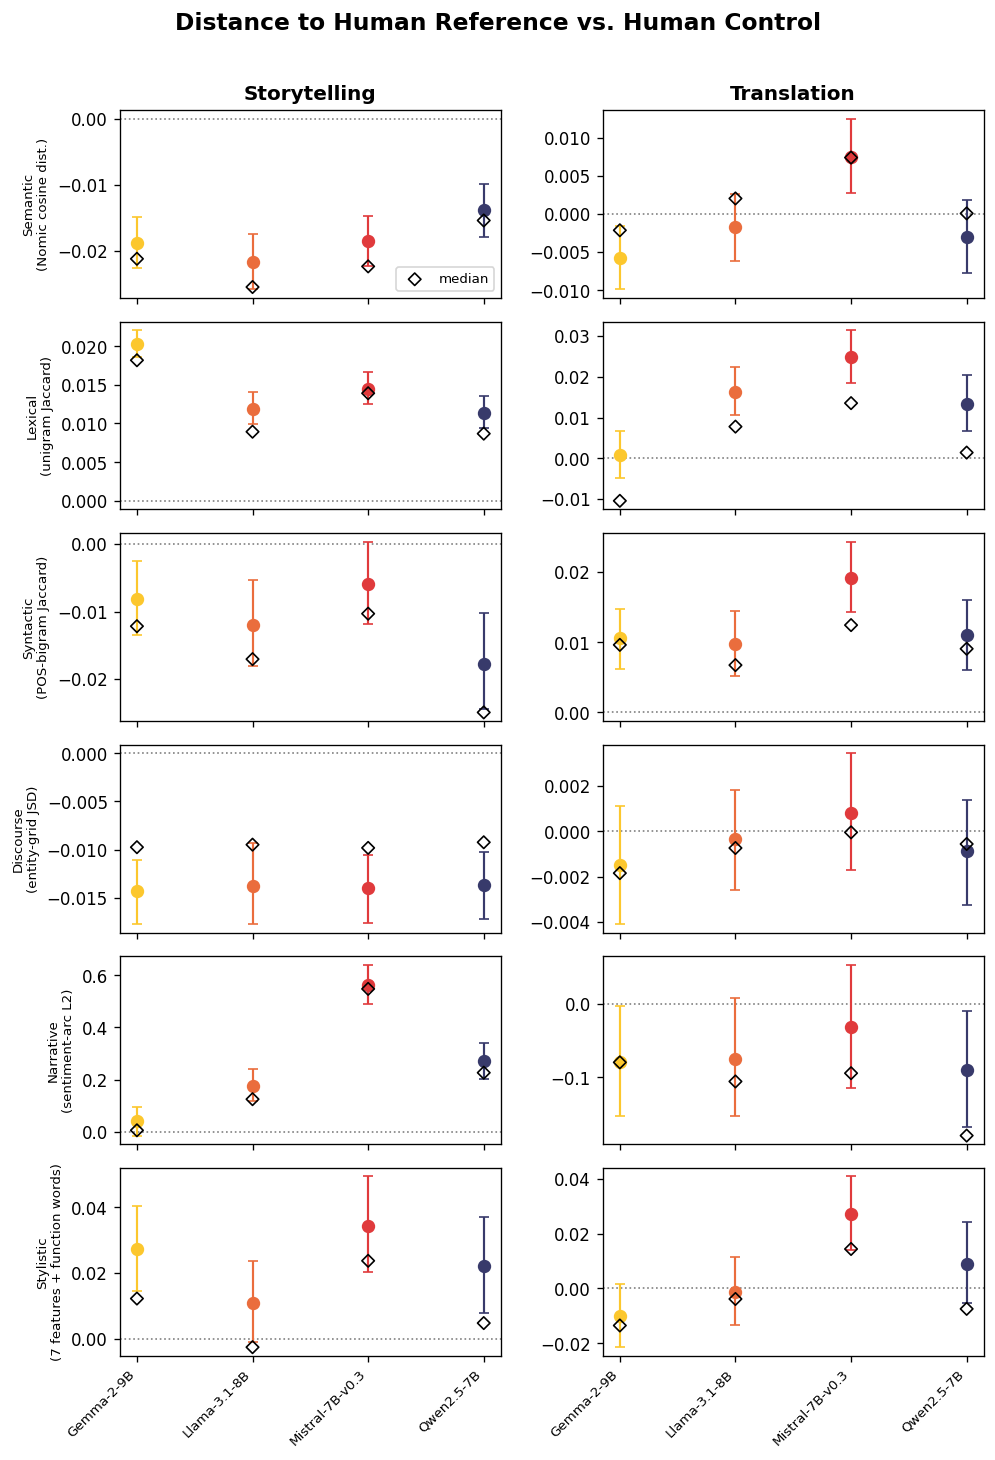

Saved: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/figures/thesis_figures/delta_to_human_control_combined.png


In [87]:
delta_summary = load_hrd_table("delta_to_human_control_summary")
hrd_grid(delta_summary, draw_ci_panel, 'Distance to Human Reference vs. Human Control',
         "delta_to_human_control_combined.png", legend=True)

### Δ to human control Table

In [88]:
print("Δ to human control — mean (median) [95% bootstrap CI] (n prompts):")
display(ci_summary_table(delta_summary, "delta_to_human_control_summary_combined.csv"))

Δ to human control — mean (median) [95% bootstrap CI] (n prompts):
Saved: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/figures/thesis_figures/delta_to_human_control_summary_combined.csv


domain                                           Storytelling  \
metric                                                  D_sem   
source_label                                                    
Gemma-2-9B       -0.019 (med -0.021) [-0.023, -0.015] (n=199)   
Llama-3.1-8B     -0.022 (med -0.025) [-0.026, -0.017] (n=199)   
Mistral-7B-v0.3  -0.019 (med -0.022) [-0.022, -0.015] (n=199)   
Qwen2.5-7B        -0.014 (med -0.015) [-0.018, -0.01] (n=199)   

domain                                                     \
metric                                              D_lex   
source_label                                                
Gemma-2-9B        0.02 (med 0.018) [0.019, 0.022] (n=199)   
Llama-3.1-8B      0.012 (med 0.009) [0.01, 0.014] (n=199)   
Mistral-7B-v0.3  0.015 (med 0.014) [0.013, 0.017] (n=199)   
Qwen2.5-7B       0.011 (med 0.009) [0.009, 0.013] (n=199)   

domain                                                         \
metric                                                  D_syn   
source_label                                                    
Gemma-2-9B       -0.008 (med -0.012) [-0.013, -0.002] (n=199)   
Llama-3.1-8B     -0.012 (med -0.017) [-0.018, -0.005] (n=199)   
Mistral-7B-v0.3      -0.006 (med -0.01) [-0.012, 0.0] (n=199)   
Qwen2.5-7B        -0.018 (med -0.025) [-0.024, -0.01] (n=199)   

domain                                                         \
metric                                                 D_disc   
source_label                                                    
Gemma-2-9B        -0.014 (med -0.01) [-0.018, -0.011] (n=199)   
Llama-3.1-8B     -0.014 (med -0.009) [-0.018, -0.009] (n=199)   
Mistral-7B-v0.3   -0.014 (med -0.01) [-0.018, -0.011] (n=199)   
Qwen2.5-7B        -0.014 (med -0.009) [-0.017, -0.01] (n=199)   

domain                                                     \
metric                                             D_narr   
source_label                                                
Gemma-2-9B       0.04 (med 0.005) [-0.015, 0.096] (n=197)   
Llama-3.1-8B     0.177 (med 0.125) [0.116, 0.239] (n=197)   
Mistral-7B-v0.3   0.563 (med 0.548) [0.488, 0.64] (n=197)   
Qwen2.5-7B       0.271 (med 0.226) [0.204, 0.338] (n=197)   

domain                                                       \
metric                                              D_style   
source_label                                                  
Gemma-2-9B          0.027 (med 0.012) [0.015, 0.04] (n=199)   
Llama-3.1-8B     0.011 (med -0.003) [-0.001, 0.024] (n=199)   
Mistral-7B-v0.3     0.034 (med 0.024) [0.02, 0.049] (n=199)   
Qwen2.5-7B         0.022 (med 0.005) [0.008, 0.037] (n=199)   

domain                                           Translation  \
metric                                                 D_sem   
source_label                                                   
Gemma-2-9B       -0.006 (med -0.002) [-0.01, -0.002] (n=195)   
Llama-3.1-8B      -0.002 (med 0.002) [-0.006, 0.003] (n=199)   
Mistral-7B-v0.3     0.007 (med 0.007) [0.003, 0.012] (n=199)   
Qwen2.5-7B          -0.003 (med 0.0) [-0.008, 0.002] (n=180)   

domain                                                      \
metric                                               D_lex   
source_label                                                 
Gemma-2-9B       0.001 (med -0.01) [-0.005, 0.007] (n=196)   
Llama-3.1-8B      0.016 (med 0.008) [0.011, 0.022] (n=200)   
Mistral-7B-v0.3   0.025 (med 0.014) [0.019, 0.031] (n=200)   
Qwen2.5-7B         0.013 (med 0.001) [0.007, 0.02] (n=181)   

domain                                                     \
metric                                              D_syn   
source_label                                                
Gemma-2-9B        0.011 (med 0.01) [0.006, 0.015] (n=196)   
Llama-3.1-8B      0.01 (med 0.007) [0.005, 0.014] (n=200)   
Mistral-7B-v0.3  0.019 (med 0.012) [0.014, 0.024] (n=200)   
Qwen2.5-7B       0.011 (med 0.009) [0.006, 0.016] (n=181)   

domain                

### r(t) per prompt

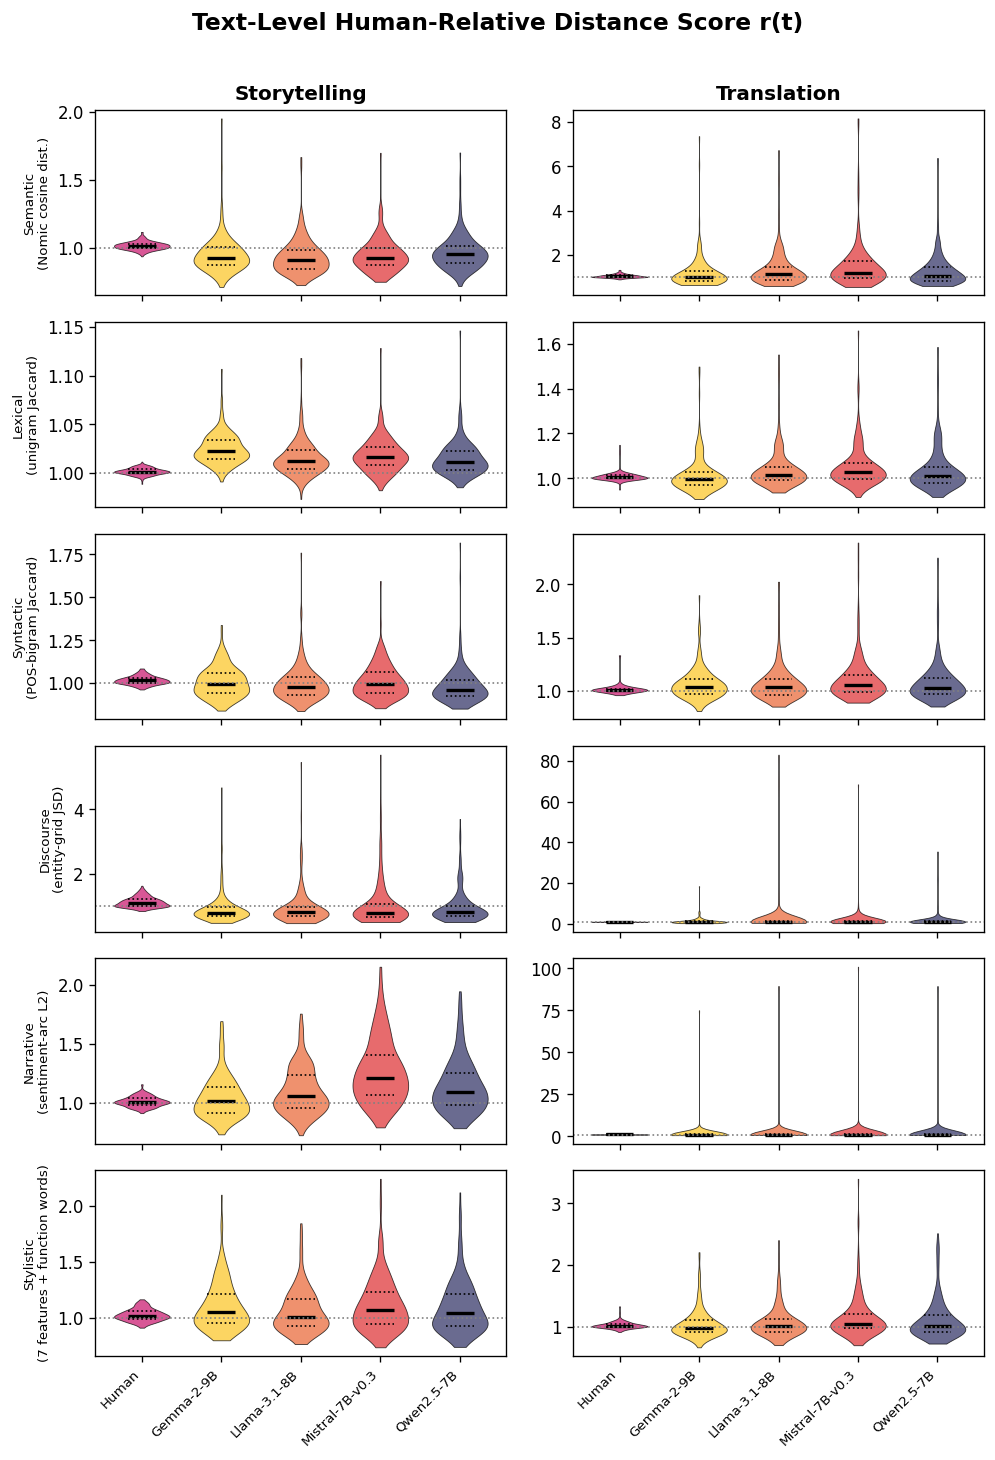

Saved: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/figures/thesis_figures/hrd_score_per_text_violin_combined.png


In [89]:
hrd_score = load_hrd_table("hrd_score_per_text")


def per_prompt(col):
    """Mean of `col` per (metric, source, prompt), renamed to `r`."""
    return {d: df.groupby(['metric', 'source', 'prompt_id'])[col].mean().rename('r').reset_index()
            for d, df in hrd_score.items()}


hrd_grid(per_prompt('r_mean'), draw_r_violin_panel, 'Text-Level Human-Relative Distance Score r(t)',
         "hrd_score_per_text_violin_combined.png")

### r_min(t) per prompt: nearest-reference robustness

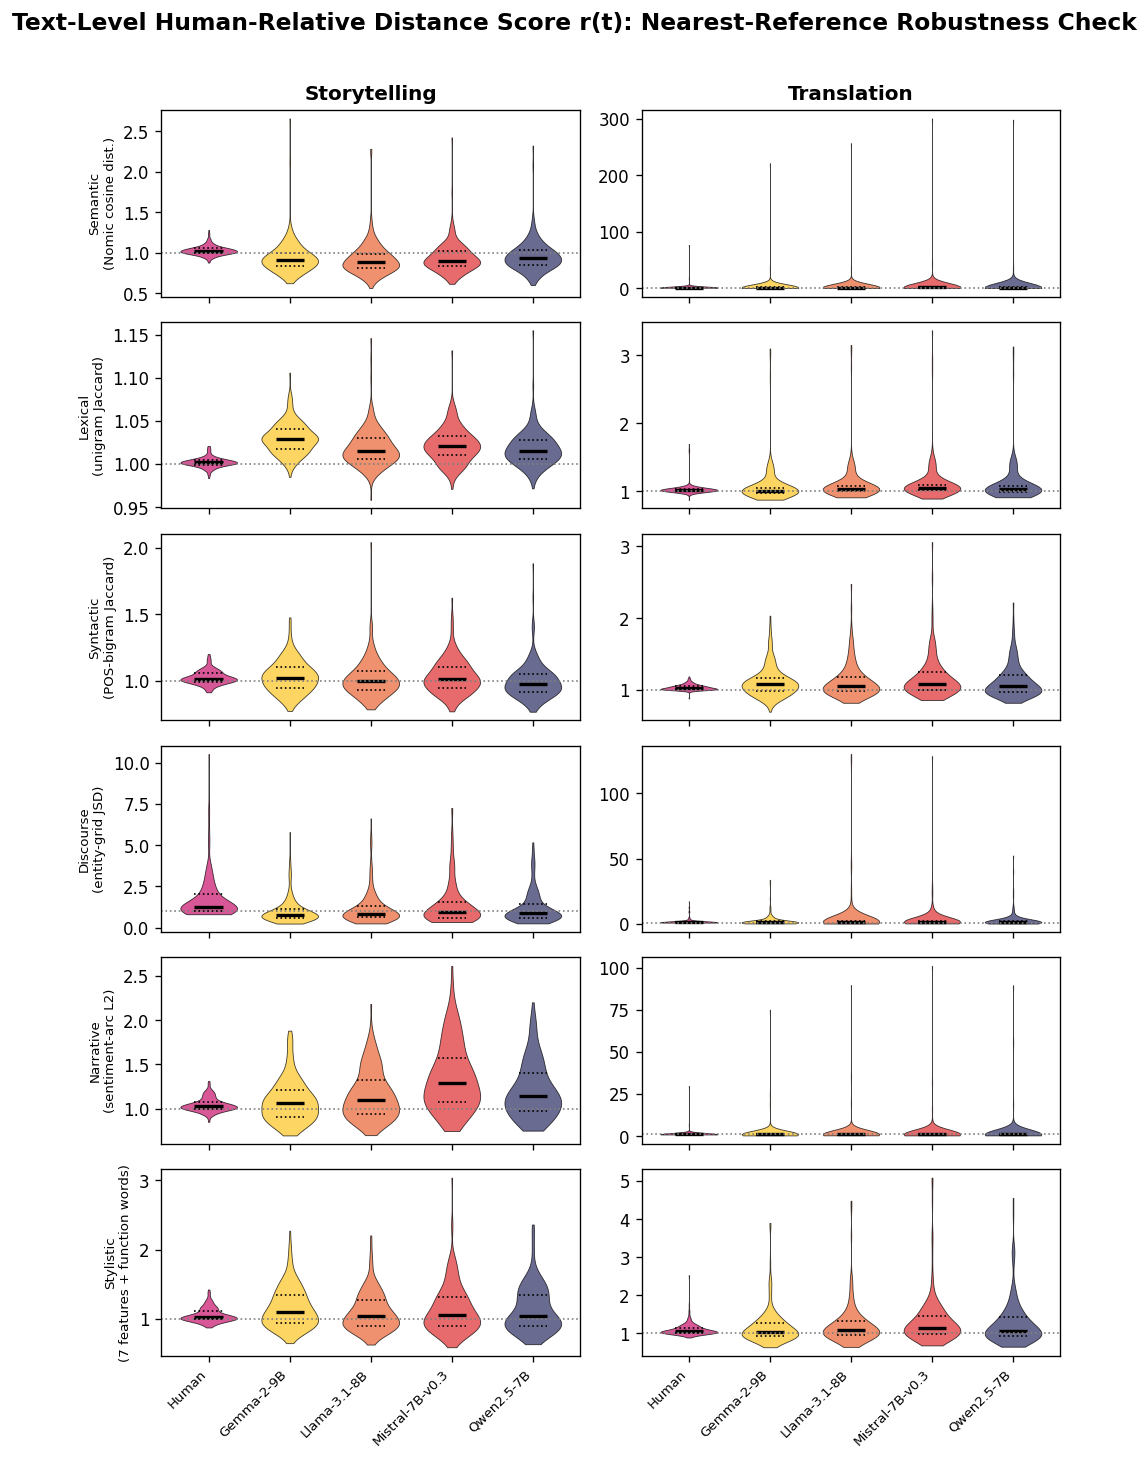

Saved: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/figures/thesis_figures/hrd_score_per_text_rmin_violin_combined.png


In [90]:
hrd_grid(per_prompt('r_min'), draw_r_violin_panel,
         'Text-Level Human-Relative Distance Score r(t): Nearest-Reference Robustness Check',
         "hrd_score_per_text_rmin_violin_combined.png")

### Energy distance

$E(H, M) = 2\,\overline{d(H, M)} - \overline{d(H, H')} - \overline{d(M, M')}$ — prompts with ≥ 3 human references.

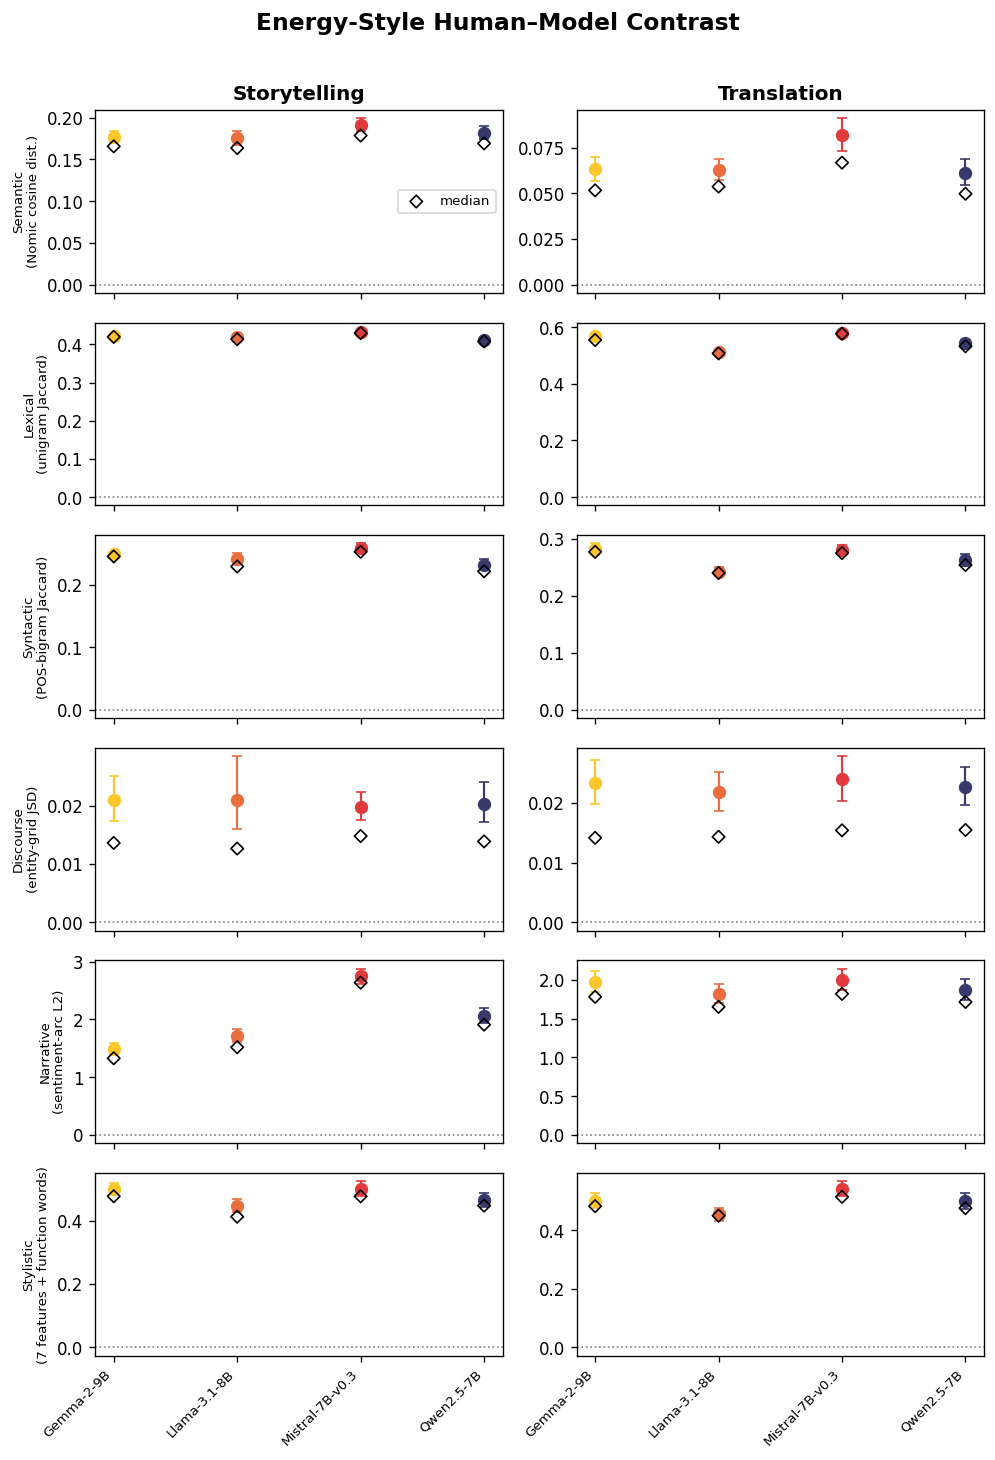

Saved: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/figures/thesis_figures/energy_distance_combined.png


In [91]:
energy_summary = load_hrd_table("energy_distance_summary")
hrd_grid(energy_summary, draw_ci_panel, 'Energy-Style Human–Model Contrast',
         "energy_distance_combined.png", legend=True)

### Energy distance Table

In [92]:
print("Energy distance E(Human, Model) — mean (median) [95% bootstrap CI] (n prompts):")
display(ci_summary_table(energy_summary, "energy_distance_summary_combined.csv"))

Energy distance E(Human, Model) — mean (median) [95% bootstrap CI] (n prompts):
Saved: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/figures/thesis_figures/energy_distance_summary_combined.csv


domain                                       Storytelling  \
metric                                              D_sem   
source_label                                                
Gemma-2-9B        0.177 (med 0.166) [0.17, 0.185] (n=199)   
Llama-3.1-8B     0.175 (med 0.164) [0.167, 0.184] (n=199)   
Mistral-7B-v0.3  0.192 (med 0.179) [0.185, 0.199] (n=199)   
Qwen2.5-7B        0.182 (med 0.169) [0.174, 0.19] (n=199)   

domain                                                     \
metric                                              D_lex   
source_label                                                
Gemma-2-9B        0.422 (med 0.419) [0.42, 0.425] (n=199)   
Llama-3.1-8B      0.42 (med 0.413) [0.416, 0.426] (n=199)   
Mistral-7B-v0.3  0.432 (med 0.429) [0.429, 0.435] (n=199)   
Qwen2.5-7B        0.412 (med 0.408) [0.41, 0.415] (n=199)   

domain                                                     \
metric                                              D_syn   
source_label                                                
Gemma-2-9B       0.249 (med 0.246) [0.244, 0.255] (n=199)   
Llama-3.1-8B      0.242 (med 0.23) [0.233, 0.252] (n=199)   
Mistral-7B-v0.3   0.26 (med 0.253) [0.253, 0.267] (n=199)   
Qwen2.5-7B       0.232 (med 0.222) [0.224, 0.241] (n=199)   

domain                                                     \
metric                                             D_disc   
source_label                                                
Gemma-2-9B       0.021 (med 0.014) [0.017, 0.025] (n=199)   
Llama-3.1-8B     0.021 (med 0.013) [0.016, 0.029] (n=198)   
Mistral-7B-v0.3   0.02 (med 0.015) [0.018, 0.022] (n=199)   
Qwen2.5-7B        0.02 (med 0.014) [0.017, 0.024] (n=199)   

domain                                                     \
metric                                             D_narr   
source_label                                                
Gemma-2-9B       1.486 (med 1.326) [1.394, 1.583] (n=197)   
Llama-3.1-8B      1.72 (med 1.518) [1.613, 1.833] (n=196)   
Mistral-7B-v0.3   2.743 (med 2.636) [2.609, 2.88] (n=197)   
Qwen2.5-7B       2.061 (med 1.909) [1.935, 2.189] (n=197)   

domain                                                     \
metric                                            D_style   
source_label                                                
Gemma-2-9B          0.5 (med 0.477) [0.48, 0.519] (n=199)   
Llama-3.1-8B     0.447 (med 0.412) [0.425, 0.469] (n=198)   
Mistral-7B-v0.3    0.5 (med 0.476) [0.477, 0.524] (n=199)   
Qwen2.5-7B       0.464 (med 0.447) [0.443, 0.486] (n=198)   

domain                                        Translation  \
metric                                              D_sem   
source_label                                                
Gemma-2-9B        0.063 (med 0.052) [0.057, 0.07] (n=195)   
Llama-3.1-8B     0.063 (med 0.054) [0.057, 0.069] (n=199)   
Mistral-7B-v0.3  0.082 (med 0.067) [0.073, 0.091] (n=199)   
Qwen2.5-7B        0.061 (med 0.05) [0.055, 0.069] (n=180)   

domain                                                     \
metric                                              D_lex   
source_label                                                
Gemma-2-9B        0.569 (med 0.555) [0.56, 0.579] (n=196)   
Llama-3.1-8B      0.512 (med 0.507) [0.505, 0.52] (n=200)   
Mistral-7B-v0.3  0.579 (med 0.577) [0.571, 0.587] (n=200)   
Qwen2.5-7B       0.544 (med 0.533) [0.533, 0.556] (n=181)   

domain                                                     \
metric                                              D_syn   
source_label                                                
Gemma-2-9B       0.282 (med 0.277) [0.272, 0.292] (n=196)   
Llama-3.1-8B       0.242 (med 0.24) [0.234, 0.25] (n=200)   
Mistral-7B-v0.3   0.281 (med 0.275) [0.272, 0.29] (n=200)   
Qwen2.5-7B       0.262 (med 0.254) [0.252, 0.273] (n=181)   

domain                                                     \
metric                                             D_disc   
source_label              

### Sensitivity: complete prompts (Translation only)

In [93]:
df_complete = pd.read_csv(HRD_TABLE_DIRS["translation_ref3"] / "delta_to_human_control_complete_prompts.csv")
df_complete['formatted'] = fmt_ci(df_complete)
save_csv(df_complete, "delta_to_human_control_complete_prompts_translation.csv", index=False)

df_complete['source_label'] = df_complete['source'].map(constants.MODEL_LABELS)
print("Translation — complete-split sensitivity: mean (median) [95% bootstrap CI] (n prompts):")
display(df_complete.pivot(index='source_label', columns='metric', values='formatted')
        .reindex(index=MODEL_LABEL_ORDER, columns=PAIRING_METRICS))

Saved: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/figures/thesis_figures/delta_to_human_control_complete_prompts_translation.csv
Translation — complete-split sensitivity: mean (median) [95% bootstrap CI] (n prompts):


metric,D_sem,D_lex,D_syn,D_disc,D_narr,D_style
source_label,,,,,,
Gemma-2-9B,"-0.004 (med -0.001) [-0.008, 0.001] (n=178)","0.002 (med -0.01) [-0.004, 0.008] (n=179)","0.011 (med 0.01) [0.006, 0.015] (n=179)","-0.001 (med -0.001) [-0.004, 0.002] (n=174)","-0.077 (med -0.069) [-0.15, -0.006] (n=153)","-0.007 (med -0.011) [-0.019, 0.005] (n=179)"
Llama-3.1-8B,"0.001 (med 0.004) [-0.003, 0.006] (n=178)","0.019 (med 0.009) [0.012, 0.025] (n=179)","0.012 (med 0.007) [0.007, 0.017] (n=179)","0.0 (med -0.0) [-0.002, 0.003] (n=174)","-0.067 (med -0.068) [-0.142, 0.005] (n=153)","0.005 (med 0.007) [-0.007, 0.018] (n=179)"
Mistral-7B-v0.3,"0.01 (med 0.009) [0.005, 0.016] (n=178)","0.027 (med 0.017) [0.02, 0.034] (n=179)","0.021 (med 0.015) [0.016, 0.027] (n=179)","0.002 (med 0.001) [-0.001, 0.005] (n=174)","-0.032 (med -0.058) [-0.11, 0.046] (n=153)","0.034 (med 0.017) [0.02, 0.048] (n=179)"
Qwen2.5-7B,"-0.002 (med 0.0) [-0.007, 0.003] (n=178)","0.014 (med 0.002) [0.007, 0.021] (n=179)","0.011 (med 0.009) [0.006, 0.016] (n=179)","-0.0 (med -0.0) [-0.003, 0.002] (n=174)","-0.082 (med -0.148) [-0.155, -0.012] (n=153)","0.01 (med -0.007) [-0.004, 0.026] (n=179)"


### Sensitivity: exactly 3 human references (Translation only)

In [94]:
df_3humans = pd.read_csv(HRD_TABLE_DIRS["translation_ref3"] / "delta_to_human_control_exactly_3_humans.csv")
df_3humans['formatted'] = fmt_ci(df_3humans, mean='mean_3humans', lo='ci_lo_3humans',
                                 hi='ci_hi_3humans', median=None)
save_csv(df_3humans, "delta_to_human_control_exactly_3_humans_translation.csv", index=False)

df_3humans['source_label'] = df_3humans['source'].map(constants.MODEL_LABELS)
print("Translation — exactly-3-human-references sensitivity: mean [95% bootstrap CI] (n prompts):")
display(df_3humans.pivot(index='source_label', columns='metric', values='formatted')
        .reindex(index=MODEL_LABEL_ORDER, columns=PAIRING_METRICS))

Saved: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/figures/thesis_figures/delta_to_human_control_exactly_3_humans_translation.csv
Translation — exactly-3-human-references sensitivity: mean [95% bootstrap CI] (n prompts):


metric,D_sem,D_lex,D_syn,D_disc,D_narr,D_style
source_label,,,,,,
Gemma-2-9B,"-0.007 [-0.012, -0.002] (n=130)","-0.007 [-0.013, -0.001] (n=130)","0.007 [0.002, 0.012] (n=130)","-0.001 [-0.005, 0.003] (n=129)","-0.111 [-0.2, -0.021] (n=118)","-0.014 [-0.027, 0.001] (n=130)"
Llama-3.1-8B,"-0.002 [-0.007, 0.003] (n=132)","0.01 [0.003, 0.017] (n=132)","0.008 [0.002, 0.013] (n=132)","-0.001 [-0.004, 0.002] (n=131)","-0.121 [-0.212, -0.028] (n=119)","-0.002 [-0.017, 0.013] (n=132)"
Mistral-7B-v0.3,"0.005 [-0.0, 0.01] (n=132)","0.017 [0.01, 0.024] (n=132)","0.017 [0.011, 0.022] (n=132)","0.001 [-0.003, 0.005] (n=130)","-0.064 [-0.162, 0.038] (n=119)","0.025 [0.009, 0.042] (n=132)"
Qwen2.5-7B,"-0.005 [-0.011, 0.0] (n=118)","0.004 [-0.003, 0.012] (n=118)","0.01 [0.004, 0.016] (n=118)","-0.001 [-0.005, 0.002] (n=117)","-0.137 [-0.224, -0.046] (n=107)","0.004 [-0.013, 0.023] (n=118)"


### Length confound (Spearman ρ)

In [95]:
for kind, label in [("delta", "Δ to human control"), ("energy", "energy distance")]:
    long = pd.concat([df.assign(domain=d) for d, df in load_hrd_table(f"length_confound_{kind}").items()],
                     ignore_index=True)
    save_csv(long, f"length_confound_{kind}_combined.csv", index=False)
    long['source_label'] = long['source'].map(constants.MODEL_LABELS)
    print(f"Spearman ρ(length, {label}):")
    display(domain_pivot(long, 'rho_length', MODEL_LABEL_ORDER, PAIRING_METRICS).round(3))

Saved: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/figures/thesis_figures/length_confound_delta_combined.csv
Spearman ρ(length, Δ to human control):


domain          Storytelling                                     Translation  \
metric                 D_sem  D_lex  D_syn D_disc D_narr D_style       D_sem   
source_label                                                                   
Gemma-2-9B             0.278  0.244 -0.006  0.074 -0.178  -0.061       0.451   
Llama-3.1-8B           0.333  0.268 -0.024 -0.060 -0.251  -0.072       0.384   
Mistral-7B-v0.3        0.258  0.070 -0.148 -0.231 -0.320  -0.179       0.337   
Qwen2.5-7B             0.303  0.260 -0.118 -0.151 -0.295  -0.139       0.373   

domain                                               
metric           D_lex  D_syn D_disc D_narr D_style  
source_label                                         
Gemma-2-9B       0.388  0.162  0.286  0.086   0.458  
Llama-3.1-8B     0.458  0.377  0.251  0.153   0.456  
Mistral-7B-v0.3  0.404  0.384  0.227  0.190   0.388  
Qwen2.5-7B       0.545  0.460  0.320  0.137   0.501

Saved: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/figures/thesis_figures/length_confound_energy_combined.csv
Spearman ρ(length, energy distance):


domain          Storytelling                                     Translation  \
metric                 D_sem  D_lex  D_syn D_disc D_narr D_style       D_sem   
source_label                                                                   
Gemma-2-9B             0.246  0.148  0.250  0.206  0.037   0.136      -0.041   
Llama-3.1-8B           0.195  0.169  0.318  0.284  0.131   0.059      -0.017   
Mistral-7B-v0.3        0.222  0.091  0.236  0.315  0.016  -0.030      -0.134   
Qwen2.5-7B             0.268  0.238  0.346  0.353  0.068   0.118      -0.089   

domain                                               
metric           D_lex  D_syn D_disc D_narr D_style  
source_label                                         
Gemma-2-9B      -0.116 -0.307 -0.444 -0.350  -0.138  
Llama-3.1-8B    -0.079 -0.310 -0.278 -0.284  -0.088  
Mistral-7B-v0.3 -0.090 -0.411 -0.389 -0.274  -0.225  
Qwen2.5-7B      -0.070 -0.348 -0.351 -0.335  -0.131

## Quality Analysis

Sources: `quality/hanna_quality_analysis.ipynb` (HANNA), `quality/liteval_quality_analysis.ipynb` (LitEval)

### r(t) in the quality datasets

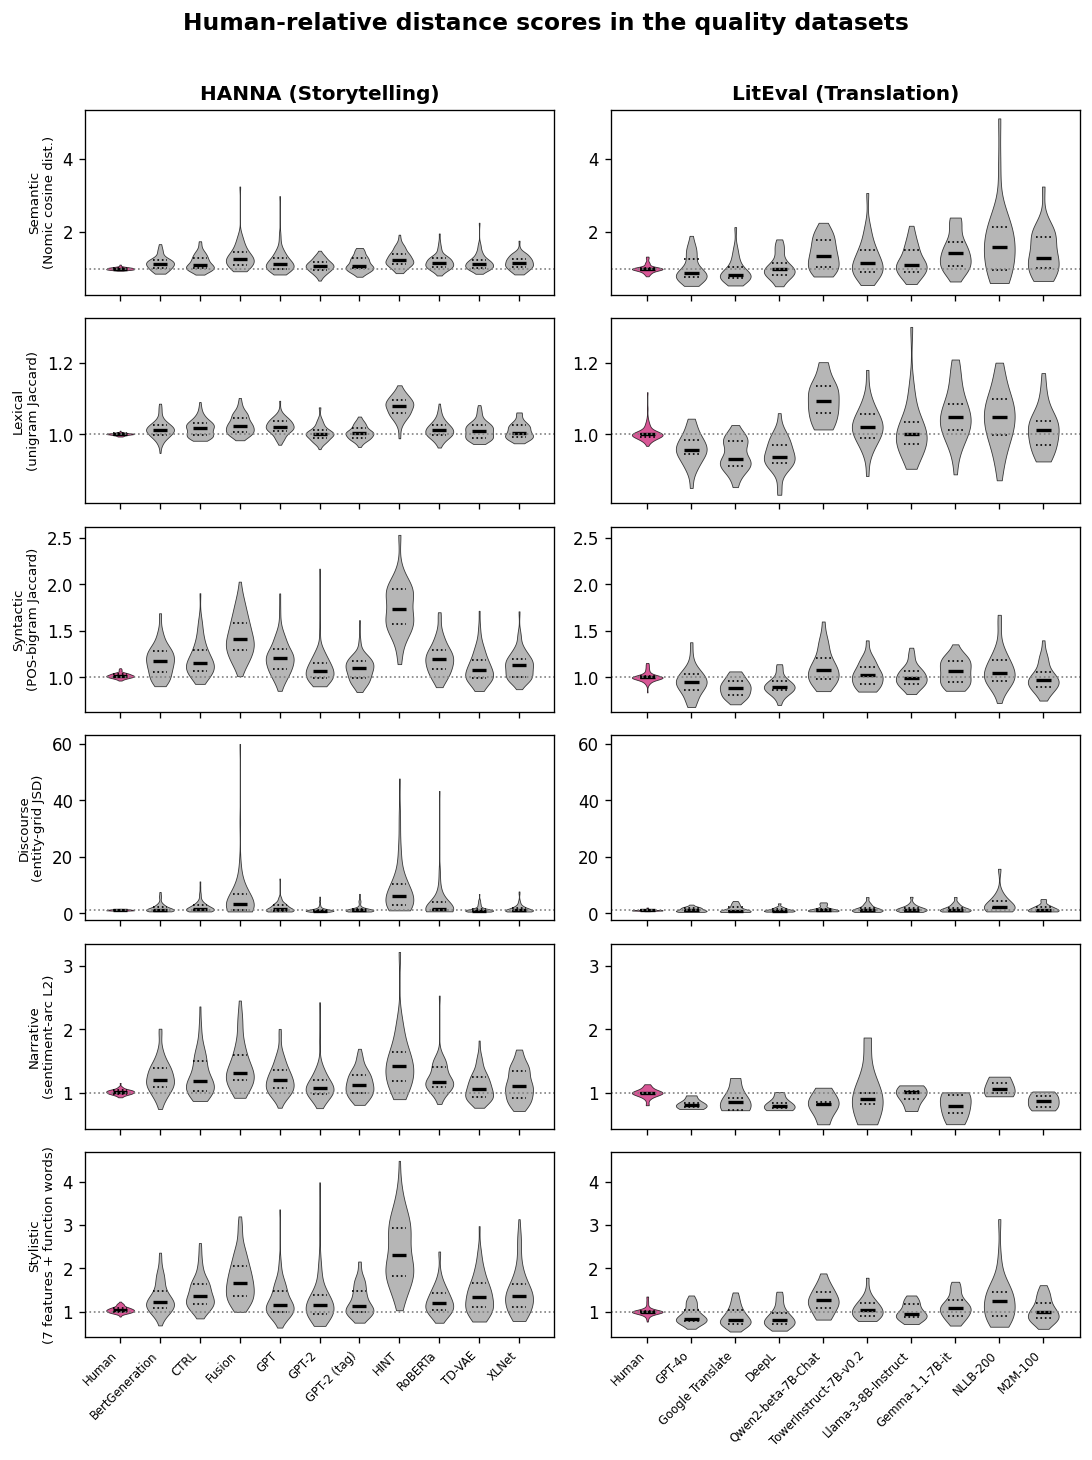

Saved: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/figures/thesis_figures/quality_hrd_score_per_text_violin_combined.png


In [96]:
QUALITY_RESULTS_DIR = REPO_ROOT / "quality" / "results"

# HANNA: average the leave-one-out human repeats to one point per (metric, source, prompt)
hanna_r_raw = pd.read_csv(QUALITY_RESULTS_DIR / "hanna_hrd_score_all.csv")
hanna_r_prompt = hanna_r_raw.groupby(["metric", "source", "prompt_key"])["r_mean"].mean().reset_index()

# LitEval: 'sem' -> 'D_sem', and normalize '_' vs. ' ' in model names
liteval_r_raw = pd.read_csv(QUALITY_RESULTS_DIR / "liteval_human_relative_scores_split_control_v3.csv")
liteval_r_raw = liteval_r_raw.assign(
    metric=("D_" + liteval_r_raw["metric"]),
    Model=liteval_r_raw["Model"].str.replace("_", " ", regex=False),
)

HT_COLOR = "#cb1f73"
MT_COLOR = "#9E9E9E"

HANNA_SOURCE_ORDER = ["human", "BertGeneration", "CTRL", "Fusion", "GPT", "GPT-2",
                      "GPT-2 (tag)", "HINT", "RoBERTa", "TD-VAE", "XLNet"]
HANNA_SOURCE_LABELS = {s: s for s in HANNA_SOURCE_ORDER} | {"human": "Human"}

LITEVAL_SOURCE_ORDER = ["translator", "gpt4o", "google translate", "deepl", "qwen2-beta-7b-chat",
                        "towerinstruct-7b-v0.2", "meta-llama-3-8b-instruct",
                        "gemma-1.1-7b-it", "nllb", "m2m"]
LITEVAL_SOURCE_LABELS = {
    "translator": "Human", "gpt4o": "GPT-4o", "google translate": "Google Translate", "deepl": "DeepL",
    "qwen2-beta-7b-chat": "Qwen2-beta-7B-Chat", "towerinstruct-7b-v0.2": "TowerInstruct-7B-v0.2",
    "meta-llama-3-8b-instruct": "Llama-3-8B-Instruct", "gemma-1.1-7b-it": "Gemma-1.1-7B-it",
    "nllb": "NLLB-200", "m2m": "M2M-100",
}

# (title, per-point data, source column, r column, source order, labels, human key) per column
QUALITY_PANELS = [
    ("HANNA (Storytelling)", hanna_r_prompt, "source", "r_mean",
     HANNA_SOURCE_ORDER, HANNA_SOURCE_LABELS, "human"),
    ("LitEval (Translation)", liteval_r_raw, "Model", "r",
     LITEVAL_SOURCE_ORDER, LITEVAL_SOURCE_LABELS, "translator"),
]

fig, axes = plt.subplots(len(PAIRING_METRICS), 2, figsize=(2 * 4.6, len(PAIRING_METRICS) * 2.0), squeeze=False)
for row, metric in enumerate(PAIRING_METRICS):
    for col, (title, df, src_col, r_col, order, labels, human) in enumerate(QUALITY_PANELS):
        ax = axes[row][col]
        sub = df[df.metric == metric]
        styled_violin(ax, [sub.loc[sub[src_col] == s, r_col].dropna().values for s in order],
                      [HT_COLOR if s == human else MT_COLOR for s in order])
        ax.axhline(1.0, color="grey", linewidth=1, linestyle=":")
        if col == 0:
            ax.set_ylabel(GROUP_METRIC_LABELS[metric], fontsize=8)
        if row == len(PAIRING_METRICS) - 1:
            ax.set_xticklabels([labels[s] for s in order], rotation=45, ha="right", fontsize=7)
        else:
            ax.set_xticklabels([])
        if row == 0:
            ax.set_title(title, fontsize=12, fontweight="bold")
    # shared y-scale within a dimension, independent across dimensions
    lo = min(ax.get_ylim()[0] for ax in axes[row])
    hi = max(ax.get_ylim()[1] for ax in axes[row])
    for ax in axes[row]:
        ax.set_ylim(lo, hi)

fig.suptitle("Human-relative distance scores in the quality datasets",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_fig("quality_hrd_score_per_text_violin_combined.png")

### r(t) in the quality datasets: descriptive statistics

In [97]:
r_summary_parts = []
for title, df, src_col, r_col, order, labels, _ in QUALITY_PANELS:
    stats = (df[df[src_col].isin(order)]
             .groupby([src_col, "metric"])[r_col]
             .agg(mean="mean", median="median", std="std", n="count")
             .reset_index()
             .rename(columns={src_col: "source"}))
    stats["source"] = stats["source"].map(labels)
    stats.insert(0, "domain", title)
    r_summary_parts.append(stats)

r_summary_df = pd.concat(r_summary_parts, ignore_index=True)
r_summary_df["mean_std"] = (
    r_summary_df["mean"].round(3).astype(str) + " ± " + r_summary_df["std"].round(3).astype(str)
    + " (med " + r_summary_df["median"].round(3).astype(str) + ")"
)
save_csv(r_summary_df, "quality_hrd_score_per_text_summary_stats.csv", index=False)

for title, _, _, _, order, labels, _ in QUALITY_PANELS:
    sub = r_summary_df[r_summary_df.domain == title]
    for values, desc in [("mean_std", "r(t): mean ± SD (median)"), ("n", "n")]:
        print(f"\n{title} — {desc}:")
        display(sub.pivot(index="source", columns="metric", values=values)
                .reindex(index=[labels[s] for s in order], columns=PAIRING_METRICS))

Saved: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/figures/thesis_figures/quality_hrd_score_per_text_summary_stats.csv

HANNA (Storytelling) — r(t): mean ± SD (median):


metric,D_sem,D_lex,D_syn,D_disc,D_narr,D_style
source,,,,,,
Human,1.009 ± 0.032 (med 1.006),1.001 ± 0.003 (med 1.001),1.019 ± 0.026 (med 1.015),1.142 ± 0.164 (med 1.129),1.013 ± 0.04 (med 1.013),1.047 ± 0.067 (med 1.041)
BertGeneration,1.155 ± 0.185 (med 1.138),1.014 ± 0.025 (med 1.013),1.181 ± 0.171 (med 1.174),1.902 ± 1.567 (med 1.292),1.255 ± 0.262 (med 1.203),1.326 ± 0.355 (med 1.226)
CTRL,1.168 ± 0.209 (med 1.109),1.018 ± 0.023 (med 1.017),1.2 ± 0.187 (med 1.16),2.232 ± 2.021 (med 1.447),1.279 ± 0.319 (med 1.179),1.446 ± 0.375 (med 1.363)
Fusion,1.338 ± 0.342 (med 1.269),1.028 ± 0.027 (med 1.024),1.445 ± 0.224 (med 1.41),5.667 ± 8.789 (med 3.136),1.418 ± 0.359 (med 1.314),1.775 ± 0.511 (med 1.658)
GPT,1.204 ± 0.314 (med 1.134),1.023 ± 0.022 (med 1.021),1.212 ± 0.186 (med 1.212),2.061 ± 1.832 (med 1.344),1.229 ± 0.252 (med 1.205),1.265 ± 0.411 (med 1.149)
GPT-2,1.085 ± 0.171 (med 1.08),1.004 ± 0.022 (med 1.002),1.101 ± 0.175 (med 1.064),1.218 ± 0.927 (med 0.895),1.117 ± 0.246 (med 1.075),1.257 ± 0.514 (med 1.148)
GPT-2 (tag),1.146 ± 0.199 (med 1.079),1.005 ± 0.018 (med 1.004),1.094 ± 0.134 (med 1.098),1.447 ± 1.251 (med 0.998),1.151 ± 0.208 (med 1.115),1.25 ± 0.343 (med 1.126)
HINT,1.28 ± 0.225 (med 1.246),1.077 ± 0.03 (med 1.08),1.747 ± 0.272 (med 1.73),8.673 ± 9.072 (med 6.005),1.478 ± 0.444 (med 1.416),2.396 ± 0.738 (med 2.311)
RoBERTa,1.184 ± 0.206 (med 1.156),1.013 ± 0.024 (med 1.012),1.207 ± 0.176 (med 1.196),3.391 ± 5.895 (med 1.587),1.237 ± 0.251 (med 1.172),1.262 ± 0.329 (med 1.199)



HANNA (Storytelling) — n:


metric,D_sem,D_lex,D_syn,D_disc,D_narr,D_style
source,,,,,,
Human,68,68,68,68,68,68
BertGeneration,68,68,68,67,64,68
CTRL,68,68,68,62,57,68
Fusion,68,68,68,61,37,68
GPT,68,68,68,64,68,68
GPT-2,68,68,68,68,66,68
GPT-2 (tag),68,68,68,68,66,68
HINT,68,68,68,54,33,67
RoBERTa,68,68,68,65,59,68



LitEval (Translation) — r(t): mean ± SD (median):


metric,D_sem,D_lex,D_syn,D_disc,D_narr,D_style
source,,,,,,
Human,1.012 ± 0.107 (med 1.0),1.003 ± 0.021 (med 1.0),1.008 ± 0.052 (med 1.0),1.061 ± 0.263 (med 1.0),0.996 ± 0.074 (med 1.0),1.014 ± 0.099 (med 1.0)
GPT-4o,1.008 ± 0.357 (med 0.881),0.96 ± 0.044 (med 0.957),0.95 ± 0.15 (med 0.948),1.277 ± 0.739 (med 1.148),0.825 ± 0.081 (med 0.814),0.923 ± 0.199 (med 0.841)
Google Translate,0.954 ± 0.346 (med 0.834),0.943 ± 0.043 (med 0.93),0.889 ± 0.099 (med 0.887),1.423 ± 1.23 (med 0.692),0.891 ± 0.206 (med 0.855),0.898 ± 0.234 (med 0.814)
DeepL,1.055 ± 0.335 (med 0.988),0.946 ± 0.048 (med 0.936),0.914 ± 0.101 (med 0.897),1.198 ± 0.764 (med 0.89),0.824 ± 0.111 (med 0.795),0.887 ± 0.246 (med 0.807)
Qwen2-beta-7B-Chat,1.414 ± 0.427 (med 1.36),1.095 ± 0.055 (med 1.093),1.111 ± 0.182 (med 1.076),1.48 ± 1.051 (med 1.032),0.811 ± 0.206 (med 0.818),1.264 ± 0.29 (med 1.265)
TowerInstruct-7B-v0.2,1.283 ± 0.539 (med 1.171),1.025 ± 0.058 (med 1.02),1.031 ± 0.134 (med 1.023),1.625 ± 1.378 (med 1.169),1.001 ± 0.461 (med 0.901),1.079 ± 0.235 (med 1.05)
Llama-3-8B-Instruct,1.219 ± 0.4 (med 1.11),1.014 ± 0.08 (med 1.0),1.014 ± 0.119 (med 0.992),1.668 ± 1.325 (med 1.169),0.953 ± 0.156 (med 1.006),1.004 ± 0.193 (med 0.947)
Gemma-1.1-7B-it,1.464 ± 0.498 (med 1.42),1.056 ± 0.076 (med 1.048),1.065 ± 0.136 (med 1.073),1.7 ± 1.36 (med 1.173),0.79 ± 0.208 (med 0.794),1.121 ± 0.271 (med 1.094)
NLLB-200,1.743 ± 0.989 (med 1.584),1.046 ± 0.079 (med 1.048),1.095 ± 0.204 (med 1.043),3.493 ± 3.662 (med 2.029),1.083 ± 0.157 (med 1.053),1.298 ± 0.545 (med 1.256)



LitEval (Translation) — n:


metric,D_sem,D_lex,D_syn,D_disc,D_narr,D_style
source,,,,,,
Human,73,73,73,52,16,67
GPT-4o,26,26,26,18,5,24
Google Translate,26,26,26,18,5,24
DeepL,26,26,26,17,5,24
Qwen2-beta-7B-Chat,26,26,26,17,5,24
TowerInstruct-7B-v0.2,26,26,26,17,6,24
Llama-3-8B-Instruct,26,26,26,17,5,24
Gemma-1.1-7B-it,26,26,26,17,5,24
NLLB-200,26,26,26,17,3,24


### Diversity vs. quality criteria (Spearman)

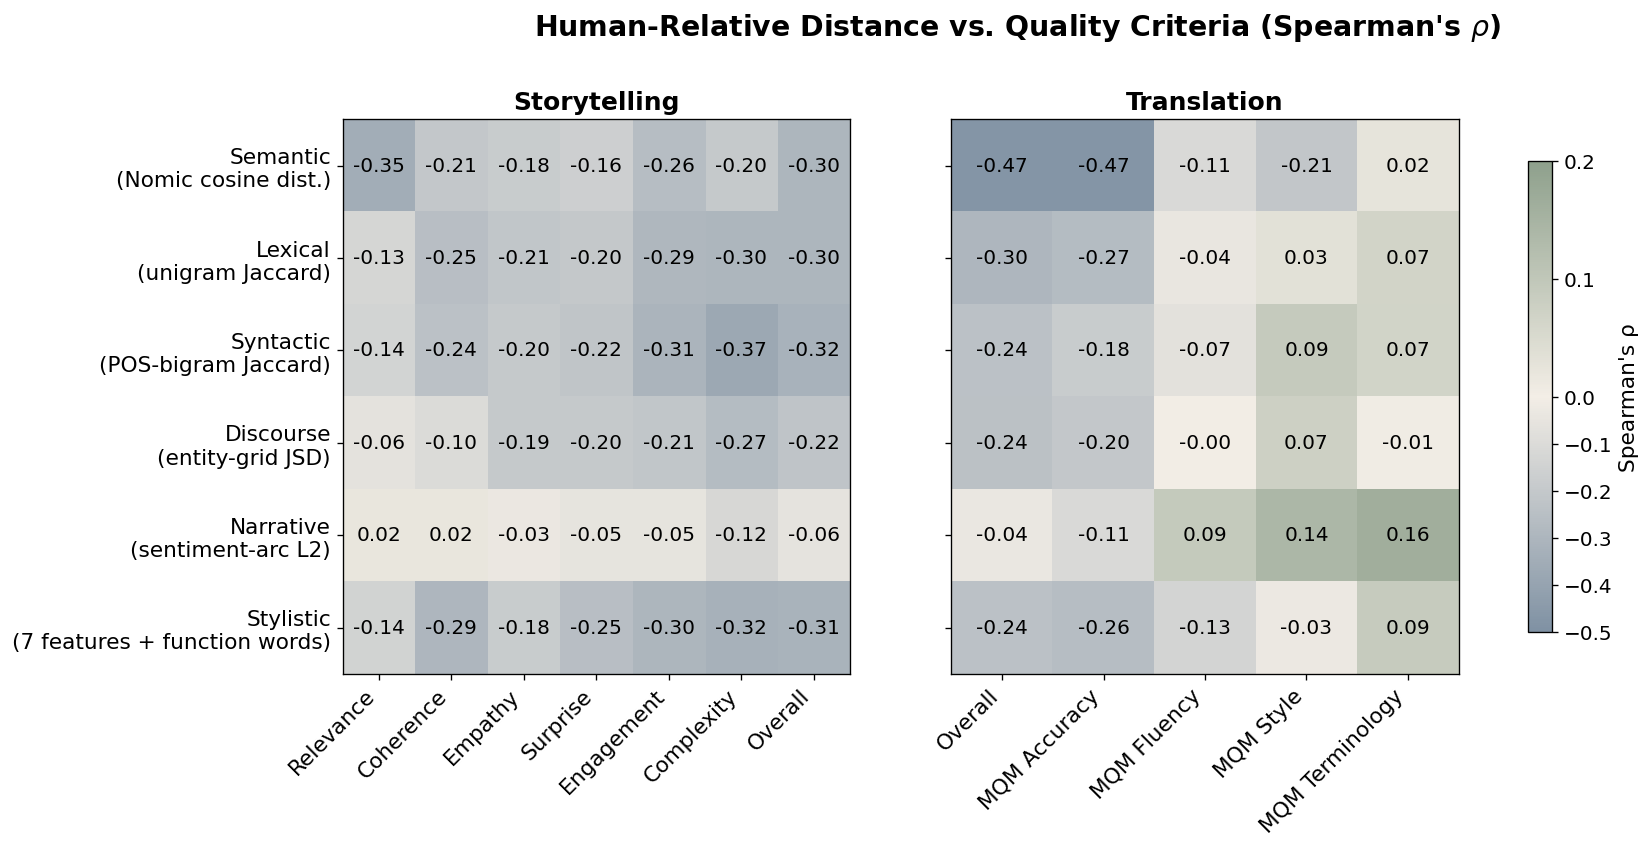

Saved: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/figures/thesis_figures/quality_dimension_correlations_combined.png
Saved: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/figures/thesis_figures/quality_dimension_correlations_combined.csv


In [98]:
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

hanna_corr = pd.read_csv(QUALITY_RESULTS_DIR / "hanna_hrd_quality_corr_all.csv")
liteval_corr = pd.read_csv(QUALITY_RESULTS_DIR / "liteval_human_relative_spearman.csv")
liteval_corr["metric"] = "D_" + liteval_corr["metric"]

QUALITY_CMAP = LinearSegmentedColormap.from_list("blue_cream_green", ["#7f91a3", "#f3eee6", "#8ea08c"])
norm = TwoSlopeNorm(vmin=-0.5, vcenter=0, vmax=0.2)

HANNA_CRITERIA = ['Relevance', 'Coherence', 'Empathy', 'Surprise', 'Engagement', 'Complexity', 'Overall']
LITEVAL_CRITERIA = ['Overall', 'MQM_Accuracy', 'MQM_Fluency', 'MQM_Style', 'MQM_Terminology']

quality_panels = {
    "storytelling_n200": (
        hanna_corr[hanna_corr.score == 'r_mean']
        .pivot(index='metric', columns='criterion', values='rho')
        .reindex(index=PAIRING_METRICS, columns=HANNA_CRITERIA)
    ),
    "translation_ref3": (
        liteval_corr.pivot(index='metric', columns='target', values='rho')
        .reindex(index=PAIRING_METRICS, columns=LITEVAL_CRITERIA)
    ),
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, domain in zip(axes, DOMAINS):
    df = quality_panels[domain]
    values = df.to_numpy(dtype=float)
    im = ax.imshow(values, cmap=QUALITY_CMAP, norm=norm, aspect="auto")
    for i, j in zip(*np.where(np.isfinite(values))):
        ax.text(j, i, f"{values[i, j]:.2f}", ha="center", va="center", fontsize=12)
    ax.set_xticks(range(len(df.columns)))
    ax.set_xticklabels([c.replace("_", " ") for c in df.columns], rotation=45, ha="right", fontsize=13)
    ax.set_yticks(range(len(PAIRING_METRICS)))
    ax.set_yticklabels([GROUP_METRIC_LABELS[m] for m in PAIRING_METRICS] if domain == DOMAINS[0] else [],
                       fontsize=13)
    ax.set_title(DOMAIN_LABELS[domain], fontsize=15, fontweight="bold")

fig.suptitle("Human-Relative Distance vs. Quality Criteria (Spearman's $\\rho$)",
             fontsize=17, fontweight="bold", y=1.03)
cbar = fig.colorbar(im, ax=axes, shrink=0.85, ticks=np.arange(norm.vmin, norm.vmax + 0.01, 0.1))
cbar.set_label("Spearman's ρ", fontsize=13)
cbar.ax.tick_params(labelsize=12)
save_fig("quality_dimension_correlations_combined.png")

combined_long = pd.concat([
    hanna_corr.loc[hanna_corr.score == 'r_mean', ['metric', 'criterion', 'rho', 'p', 'n']]
        .rename(columns={'criterion': 'target'}).assign(domain='storytelling_n200'),
    liteval_corr[['metric', 'target', 'rho', 'n']].assign(domain='translation_ref3'),
], ignore_index=True)
save_csv(combined_long, "quality_dimension_correlations_combined.csv", index=False)

## Case Study: `wp_0063`

Source: `metrics/06_writingprompts_diversity/writingprompts_diversity.ipynb`

In [99]:
CASE_PROMPT_ID = "wp_0063"
CASE_MODEL_KEY = "gemma"
CASE_METRICS = ["D_style", "D_disc", "D_narr"]

wp_results = pd.read_csv(HRD_TABLE_DIRS["storytelling_n200"] / "writingprompts_diversity_results.csv")
case_rows = wp_results[wp_results.prompt_id == CASE_PROMPT_ID].set_index("model_key")

human_label = constants.MODEL_LABELS["human"]
case_model_label = constants.MODEL_LABELS[CASE_MODEL_KEY]
case_table = pd.DataFrame({
    human_label: case_rows.loc["human", CASE_METRICS],
    case_model_label: case_rows.loc[CASE_MODEL_KEY, CASE_METRICS],
})
case_table["Human - Model"] = case_table[human_label] - case_table[case_model_label]

save_csv(case_table, "case_study_wp0063_diversity_scores.csv")
print(f"Prompt-level diversity scores for {CASE_PROMPT_ID} (Human vs. {case_model_label}):")
display(case_table.round(3))

Saved: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/figures/thesis_figures/case_study_wp0063_diversity_scores.csv
Prompt-level diversity scores for wp_0063 (Human vs. Gemma-2-9B):


,Human,Gemma-2-9B,Human - Model
D_style,1.000,0.253,0.747
D_disc,0.021,0.006,0.015
D_narr,1.990,2.715,-0.724


In [100]:
import textwrap

from common import data_prep

# Same quality filter and human 5-cap as the source notebook -> the exact sets scored above
case_texts = data_prep.load_texts("storytelling_n200", n_prompts=200)
case_texts = (
    case_texts[(case_texts.raw_prompt_id == CASE_PROMPT_ID) & case_texts.source.isin(["human", CASE_MODEL_KEY])]
    .assign(_order=lambda d: d.source.map({"human": 0, CASE_MODEL_KEY: 1}))
    .sort_values(["_order", "story_id"])
    .drop(columns="_order")
)

save_csv(case_texts[["source", "model", "story_id", "prompt", "text"]],
         f"case_study_{CASE_PROMPT_ID.replace('_', '')}_continuations.csv", index=False)

print(f"\nPrompt {CASE_PROMPT_ID}:")
print(textwrap.fill(case_texts.iloc[0]["prompt"], width=98))

for source in ["human", CASE_MODEL_KEY]:
    group = case_texts[case_texts.source == source]
    print("\n" + "=" * 98)
    print(f"{constants.MODEL_LABELS[source]} — {len(group)} continuations")
    print("=" * 98)
    for _, row in group.iterrows():
        print(f"\n--- #{row['story_id']}  ({len(row['text'].split())} words, {len(row['text'])} characters) ---")
        for para in row["text"].split("\n"):
            print(textwrap.fill(para, width=98) if para.strip() else "")

Saved: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/figures/thesis_figures/case_study_wp0063_continuations.csv

Prompt wp_0063:
When you reach the age of 25, you will respawn back to 25 anytime you die. When you reach age 50,
you no longer respawn if you die.

Human — 5 continuations

--- #0  (298 words, 1545 characters) ---
`` Legate! Legate! The Picts are assaulting Hadrian's wall again''
`` Damn it! do you know how long I have served here boy? CL years, it's the same damn Pict that
gets me every time, crafty little bugger I nearly had him last time to.''
`` Sir?''
`` Look boy, your new here, we've been fighting the the same Pict's for over a century, we have
our own personal rivals and we all know each over by face a few unwritten rules you ought to know
though.''
`` Rules? But they are barbarians!''
`` That they maybe but these lot are n't cruel, they'll slit your throat right quick but they wont
torture you, I damn well expect the same from you. Yo